# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification.

In [ ]:
import importlib.util

RUNNING_ON_GOOGLE = True
NEED_TO_RETRAIN_THEM_ALL = True
FREE_MEM_BEFORE_ABLATION = True
REDO_ABLATION = {
    "A1": False,
    "A2": False,
    "B": False,
    "C": False,
    "D": False,
    "E": False,
    "F": False,
    "G": False
}

if RUNNING_ON_GOOGLE:
  from google.colab import drive
  drive.mount('/content/drive')
  # This path MUST BE CHANGED IN A USER BASIS !!!!!!!!!!!!
  %cd '/content/drive/MyDrive/ACADEMIA/ML4HD_LABS/PROJECT/src'

  # Check if 'mne' is already installed to avoid re-installation!! (SAVES 10 PRECIOUS SECONDS)
  if importlib.util.find_spec('mne') is None:
    %pip install mne
  if importlib.util.find_spec('loguru') is None:
    %pip install loguru

  # This is the sample file that is going to be used initially to extract general shape features from EEG
  sample_file = 3
  # for unban420
  #sample_file = 5
else:
  sample_file = 0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ACADEMIA/ML4HD_LABS/PROJECT/src


In [ ]:
import importlib
import warnings
import scipy.io
import os
import sys
import gc

# Add the current directory to the Python path to detect the utils folder
sys.path.append('.')
import utils.utils as u
import utils.preprocessing as p
import utils.models as m

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE


from tqdm.auto import tqdm
import numpy as np
import mne
import polars as pl
import pandas as pd
import seaborn as sns
from loguru import logger
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP
from itertools import groupby
from scipy.signal import butter, filtfilt
import json
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Any
from collections import defaultdict


mne.set_log_level('WARNING')
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)


def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


config = {
    ## GENERAL
    "seed": 42,
    ## DATA SPLITTING AND AUGMENTATION
    # this hyperparameter controls how many files are ingested (in case we are using a lower-end commodity pc for example, 16gb of ram is not enough)
    "input_file_limit": 100,
    "experiment": "CLA",
    "DO_INTERMEDIATE_SAVING": False,
    # This would produce a split of size 80/10/10 with augmentation x3
    "train_data_proportion": 0.8,
    "val_test_data_ratio": 0.5,
    "augment_factor": 1 ,
    ## Preprocessing
    "sampling_rate": 200,
    "window_size": 2.0,
    ## Deep Learning General Hyperparameters
    "batch_size": 64,
    "lr": 1e-4,
    "epochs": 10,
    "patience": 3,

}
set_seed(config["seed"])


## 0. Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018.

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [ ]:
# Get the file names from directory of the files of the experiment
experiment = config["experiment"]
print(experiment)
files=u.get_file_names("../data", experiment=experiment)
files = files[:config["input_file_limit"]]
logger.info("The following {} files where found: {}", experiment, files)

2026-01-25 08:46:28.675 | INFO     | __main__:<cell line: 0>:6 - The following CLA files where found: ['../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectA-160108-3St-LRHand.mat']


CLA


In [ ]:
def load_mat_file(FILE):
    """Load a .mat file and return its contents."""
    skip=False
    mat_data = scipy.io.loadmat(FILE)
    # The file includes metadata coming from python that we don't need.
    # We will focus on the 'o' key which contains the EEG data and information about the experiment.
    data = mat_data['o'][0, 0]
    sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
    eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
    channel_names = [
        str(ch[0]).strip("[]' ")
        for ch in data["chnames"]
    ]
    info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
    if 'X5' in channel_names:
        info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
    else:
        logger.warning("Channel X5 not found, skipping file.")
        logger.warning(channel_names)
        skip=True
        return None, None, skip
    montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
    info.set_montage(montage)
    raw = mne.io.RawArray(eeg_data, info)
    return raw, data, skip

## 0.1. Syncronization data exploration
First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [ ]:
raw, data, _ = load_mat_file(files[sample_file])
labels = np.array(data['marker'])
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        logger.info("Marker {}: Length {}", marker, length)
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    logger.success("\nMinimum length of a non-zero marker series: {}", min(non_zero_lengths))



2026-01-25 08:46:34.511 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 209
2026-01-25 08:46:34.511 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 205
2026-01-25 08:46:34.512 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 206
2026-01-25 08:46:34.512 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 207
2026-01-25 08:46:34.513 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 206
2026-01-25 08:46:34.520 | SUCCESS  | __main__:<cell line: 0>:12 - 
Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

2026-01-25 08:46:34.536 | INFO     | __main__:<cell line: 0>:9 - Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
2026-01-25 08:46:34.538 | INFO     | __main__:<cell line: 0>:11 - Spike indixes:[328 329 330 331 332 333 334 335 336 346]
2026-01-25 08:46:34.539 | INFO     | __main__:<cell line: 0>:13 - Compute gaps:[ 1  1  1  1  1  1  1  1 10  1]
2026-01-25 08:46:34.540 | INFO     | __main__:<cell line: 0>:16 - Indices in gaps:[ 8 12 23 27 35 49 53 68 73 86]
2026-01-25 08:46:34.556 | INFO     | __main__:<cell line: 0>:29 - Spike onsets in the plotted window: [100091 100789 101317 101903]


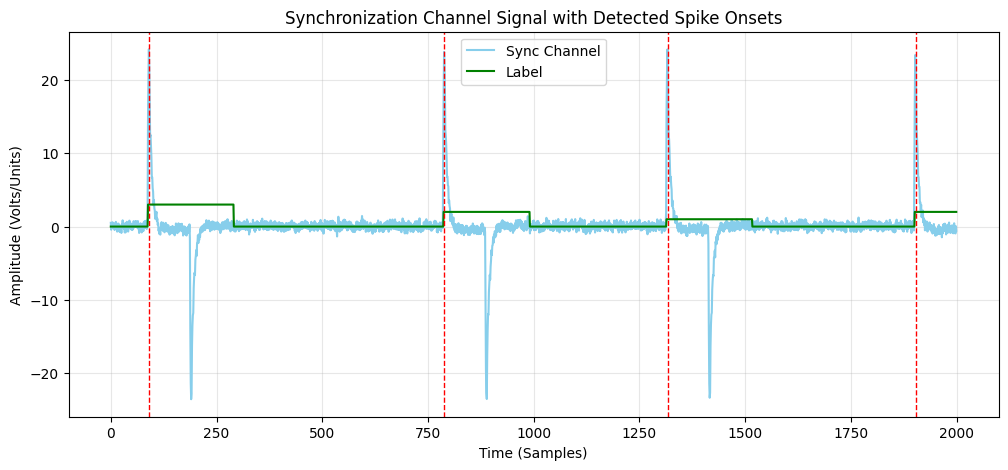

In [ ]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
logger.info(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
logger.info(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
logger.info(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
logger.info(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
logger.info(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

## 1. PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

Quoting [Altaheri23]: "Pre-processing is generally performed in three main
steps: channel selection, signal frequency filtering, and
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment)
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")\n
 A high-pass cutoff has been passed.

2. Robust Referencing
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance.

3. Bad Channel Interpolation
THIS CAN BE DONE

(4. Rereferencing or undo interpolation)


In [ ]:
def PREP(raw):
    # --- High-pass cutoff ---
    raw.filter(l_freq=1.0, h_freq=None)
    # --- Laplace Reference (Surface Laplacian) ---
    # In MNE, this is often done by calculating the Surface Laplacian.
    raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))
    return raw_laplace

Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [ ]:
def create_epochs(raw_laplace, data):

    markers_diff = np.diff(data["marker"].squeeze())
    all_transition_indices = np.where(markers_diff != 0)[0] + 1
    all_values = data["marker"].squeeze()[all_transition_indices]
    valid_mask = (all_values != 0) & (all_values < 90)
    event_samples_filtered = all_transition_indices[valid_mask]
    event_values_filtered = all_values[valid_mask]

    # Reconstruct the events array
    event_count = len(event_samples_filtered)
    events = np.column_stack([
        event_samples_filtered,
        np.zeros(event_count, dtype=int),
        event_values_filtered
    ]).astype(int)

    epochs_laplace = mne.Epochs(
        raw=raw_laplace,
        events=events,
        tmin=0,
        tmax=0.85,
        baseline=None,
        preload=True
    )
    return epochs_laplace

In [ ]:
all_X = []
all_y = []

for file in files:
    raw, data, skip = load_mat_file(file)
    if skip:
        continue

    # Resample raw data to a consistent sampling rate before further processing
    # This ensures all epochs will have the same number of time points.
    if raw.info['sfreq'] != config["sampling_rate"]:
        raw.resample(sfreq=config["sampling_rate"])

    raw_laplace = PREP(raw)
    epochs_laplace = create_epochs(raw_laplace, data) # create_epochs will use the sfreq from raw_laplace

    # Get the data and labels
    X_tmp = epochs_laplace.get_data()  # Shape: (n_epochs, n_channels, n_times)
    y_tmp = epochs_laplace.events[:, 2] # Shape: (n_epochs,)

    logger.info(f"\n File: {file}")
    logger.info(f"  X shape: {X_tmp.shape}")
    logger.info(f"  y shape: {y_tmp.shape}")

    all_X.append(X_tmp)
    all_y.append(y_tmp)


# Combine everything into one big array
X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

logger.info(f"Final X shape: {X.shape}") # (Total_epochs, n_channels, n_times)
logger.info(f"Final y shape: {y.shape}") # (Total_epochs,)


2026-01-25 08:46:36.136 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-25 08:46:36.137 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-25 08:46:37.982 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-25 08:46:37.983 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-25 08:46:39.910 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-25 08:46:39.911 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-25 08:46:41.336 | INFO     | __main__:<cell line: 0>:21 - 
 File: ../data/CLA-SubjectE-160122-3St-LRHand

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no.
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [ ]:
def augment_eeg_data(X, y, multiplier=3):
    if multiplier <= 1:
       return X, y
    n_trials, n_chans, n_samples = X.shape

    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=config["sampling_rate"])
    noise_candidates = filtfilt(b, a, X, axis=-1)

    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates

    X_aug_list = [X] # Start with original data
    y_aug_list = [y]

    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [ ]:
unique_labels = np.unique(y)
N = len(unique_labels)
logger.info(f"Number of classes: {N}, Classes: {unique_labels}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1-config["train_data_proportion"]), random_state=config["seed"], stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(config["val_test_data_ratio"]), random_state=config["seed"], stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=config["augment_factor"]) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
logger.info(class_weights)
logger.info("Shape of each train/val/test split is {} {} {}", X_train.shape, X_val.shape, X_test.shape)


2026-01-25 08:48:01.021 | INFO     | __main__:<cell line: 0>:3 - Number of classes: 3, Classes: [1 2 3]
2026-01-25 08:48:01.168 | INFO     | __main__:<cell line: 0>:17 - {0: np.float64(0.9678489042675894), 1: np.float64(0.9678489042675894), 2: np.float64(1.071166427317696)}
2026-01-25 08:48:01.169 | INFO     | __main__:<cell line: 0>:18 - Shape of each train/val/test split is (10740, 21, 171) (1343, 21, 171) (1343, 21, 171)


## 2. FEATURE EXTRACTION and DATA PREPARATION
As summarized in [Altaheri23], EEG signals can be approched in 4 different ways:

1. Extracting features
2. Using spectral images
3. Directly using the raw preprocessed data
4. Using topological maps

For **1. Extracting features** we will follow the two main suggested approaches in [Altaheri23]: "Luo et al. utilized FBCSP to extract spatial-frequency sequential time slices from MI-EEG signals and classified them using long short-term memory (LSTM) and gated
recurrent unit (GRU) models. The proposed method achieved good results for both recurrent models. In, the authors also used the FBCSP approach to extract spatial features from MI data and fed them into a CNN model as a 2D matrix."

Our approach is not exactly the same to the one found on the papers cited but it is inspired by them. It will be explained why and how later. The two papers are:

T. Luo and F. Chao, “Exploring spatial-frequency-sequential
relationships for motor imagery classification with recurrent neural
network,” BMC Bioinformatics, vol. 19, no. 1, p. 344, 2018.

https://www.researchgate.net/publication/327967384_Exploring_spatial-frequency-sequential_relationships_for_motor_imagery_classification_with_recurrent_neural_network

B. E. Olivas-Padilla and M. I. Chacon-Murguia, “Classification of
multiple motor imagery using deep convolutional neural networks
and spatial filters,” Appl. Soft Comput., vol. 75, pp. 461–472, 2019.

https://www.sciencedirect.com/science/article/pii/S156849461830663X?via%3Dihub

For **3. Directly using the raw preprocessed data** we will follow the two papers suggested by the teachers in the in the project presentation: the already referenced [Zhang21] and

[Lawhern18] V. J. Lawhern, A. J. Solon, N. R. Waytowich, S. M. Gordon, C. P. Hung, and B. J. Lance,
EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces, Journal of
neural engineering, vol. 15, no. 5, p. 056013, 2018.

https://www.researchgate.net/publication/310953136_EEGNet_a_compact_convolutional_neural_network_for_EEG-based_brain-computer_interfaces

TODO: 2 or 4 or both or something else

In [ ]:
def extract_windows(dataset, W, n_steps):
    projected = np.matmul(W, dataset.astype('float32'))
    n_samples = projected.shape[-1]
    win_len = int(n_samples * 0.5)
    starts = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    windows = np.stack([projected[..., s:s+win_len] for s in starts], axis=2)
    log_var = np.log(np.var(windows, axis=-1) + 1e-10)
    return log_var

def process_band_to_matrix(X_train, y_train, X_val, X_test, sfreq):
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(X_train, y_train)
    W = csp.filters_
    train_cnn, train_rnn = extract_windows(X_train, W, 3), extract_windows(X_train, W, 15)
    val_cnn, val_rnn     = extract_windows(X_val, W, 3), extract_windows(X_val, W, 15)
    test_cnn, test_rnn   = extract_windows(X_test, W, 3), extract_windows(X_test, W, 15)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)


In [ ]:
freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
n_bands = len(freq_bands)

if not config["DO_INTERMEDIATE_SAVING"]:
    logger.info("Memory-optimized filtering enabled. Processing each split individually.")
    train_bands_list = []
    val_bands_list = []
    test_bands_list = []

    for i, (l, h) in enumerate(tqdm(freq_bands, desc="Filtering bands (Memory Optimized)")):
        train_filtered = mne.filter.filter_data(
            X_train,
            config["sampling_rate"],
            l, h,
            method='fir',
            fir_design='firwin',
            n_jobs=-1,
            copy=True, # Ensure a copy is made to avoid modifying original X_train
            verbose=False
        ).astype('float32')
        train_bands_list.append(train_filtered)

        val_filtered = mne.filter.filter_data(
            X_val,
            config["sampling_rate"],
            l, h,
            method='fir',
            fir_design='firwin',
            n_jobs=-1,
            copy=True,
            verbose=False
        ).astype('float32')
        val_bands_list.append(val_filtered)

        test_filtered = mne.filter.filter_data(
            X_test,
            config["sampling_rate"],
            l, h,
            method='fir',
            fir_design='firwin',
            n_jobs=-1,
            copy=True,
            verbose=False
        ).astype('float32')
        test_bands_list.append(test_filtered)

    train_bands = np.stack(train_bands_list, axis=0)
    val_bands = np.stack(val_bands_list, axis=0)
    test_bands = np.stack(test_bands_list, axis=0)

    # Explicitly delete temporary lists to free memory
    del train_bands_list, val_bands_list, test_bands_list
    gc.collect()

elif config["DO_INTERMEDIATE_SAVING"]:
    # This block replicates the *original* filtering and saving logic.
    # It creates a large intermediate array 'X_all_filtered.npy' on disk.

    if not os.path.exists('X_all_filtered.npy'):
        logger.info("Original filtering logic: Creating X_all_filtered intermediate array and saving to disk.")
        # Combine all data for filtering in one go
        X_all = np.concatenate([X_train, X_val, X_test], axis=0)
        X_all_filtered = np.zeros((n_bands, *X_all.shape), dtype='float32')

        for i, (l, h) in enumerate(tqdm(freq_bands, desc="Original Global Filtering")):
            X_all_filtered[i] = mne.filter.filter_data(
                X_all,
                config["sampling_rate"],
                l, h,
                method='fir',
                fir_design='firwin',
                n_jobs=-1,
                copy=False, # Modify in-place for efficiency within this block
                verbose=False
            ).astype('float32')

        np.save('X_all_filtered.npy', X_all_filtered)
        logger.info("X_all_filtered saved to disk.")
    else:
        logger.info("Original filtering logic: Loading X_all_filtered from disk.")
        X_all_filtered = np.load('X_all_filtered.npy').astype('float32')

    logger.info(f"X_all_filtered shape after loading/creation: {X_all_filtered.shape}")

    # This block replicates the *original* splitting logic.
    # It assumes 'X_all_filtered' has been created/loaded by the previous block.

    logger.info("Original splitting logic: Splitting X_all_filtered.")
    split_val = len(X_train)
    split_test = len(X_train) + len(X_val)
    train_bands = X_all_filtered[:, :split_val, :, :].astype('float32')
    val_bands = X_all_filtered[:, split_val:split_test, :, :].astype('float32')
    test_bands = X_all_filtered[:, split_test:, :, :].astype('float32')

    del X_all_filtered # Explicitly delete the large intermediate array to free memory
    gc.collect()

logger.info(f"train_bands shape: {train_bands.shape}")
logger.info(f"val_bands shape: {val_bands.shape}")
logger.info(f"test_bands shape: {test_bands.shape}")


2026-01-25 08:48:01.189 | INFO     | __main__:<cell line: 0>:5 - Memory-optimized filtering enabled. Processing each split individually.


Filtering bands (Memory Optimized):   0%|          | 0/9 [00:00<?, ?it/s]

2026-01-25 08:50:02.329 | INFO     | __main__:<cell line: 0>:98 - train_bands shape: (9, 10740, 21, 171)
2026-01-25 08:50:02.330 | INFO     | __main__:<cell line: 0>:99 - val_bands shape: (9, 1343, 21, 171)
2026-01-25 08:50:02.330 | INFO     | __main__:<cell line: 0>:100 - test_bands shape: (9, 1343, 21, 171)


In [ ]:
results = []
for i in tqdm(range(len(train_bands)), desc="Processing CSP and Windows"):
    res = process_band_to_matrix(
        train_bands[i].astype('float32'),
        y_train,
        val_bands[i].astype('float32'),
        test_bands[i].astype('float32'),
        config["sampling_rate"]
    )
    results.append(res)

# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

Processing CSP and Windows:   0%|          | 0/9 [00:00<?, ?it/s]

CNN Shape: (10740, 189, 3)
RNN Shape: (10740, 15, 189)


In [ ]:
n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [ ]:
times = epochs_laplace.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
logger.info(f"C: {C}, T: {T}, N: {N}")
logger.info("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis]
X_test = X_test[:, :, :, np.newaxis]
X_val = X_val[:, :, :, np.newaxis]

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
logger.info("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

logger.info("\n")
logger.info("#####################################################\n")
logger.info(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
logger.info(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
logger.info(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

2026-01-25 08:51:22.772 | INFO     | __main__:<cell line: 0>:5 - C: 21, T: 171, N: 3
2026-01-25 08:51:22.773 | INFO     | __main__:<cell line: 0>:6 - #####################################################

2026-01-25 08:51:22.774 | INFO     | __main__:<cell line: 0>:23 - Label map:
2026-01-25 08:51:22.780 | INFO     | __main__:<cell line: 0>:31 - 

2026-01-25 08:51:22.781 | INFO     | __main__:<cell line: 0>:32 - #####################################################

2026-01-25 08:51:22.781 | INFO     | __main__:<cell line: 0>:33 - X train shape: (10740, 21, 171, 1), X_train_features shape: (10740, 189, 3, 1), y train shape: (10740, 3)
2026-01-25 08:51:22.782 | INFO     | __main__:<cell line: 0>:34 - X test shape: (1343, 21, 171, 1), X_test_features shape: (1343, 189, 3, 1), y test shape: (1343, 3)
2026-01-25 08:51:22.783 | INFO     | __main__:<cell line: 0>:35 - X val shape: (1343, 21, 171, 1), X_val_features shape: (1343, 189, 3, 1), y val shape: (1343, 3)


In [ ]:
import tensorflow as tf
epsilon = 1e-7

def f1_score_metric(y_true, y_pred):

    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))

    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))

    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)

    return f1_val

### Data Augmentation

TODO!!!!

Neural networks are extremely data hungry machine learning algorithms, specially attention based models for the complex patterns they are able to capture. We will make use of **Tensorflow dataset API** to add transformations, preprocessing, caching, shuffling, prefetching, batching...

There are 5 possible augmentations that can enhance data volume and help improve overall generalization of trained models. Without being destructive to the signal, we can add these generic signal augmentation techniques:

1) Gaussian Noise
2) Temporal Shift
3) Random Crop + Resize
4) Channel Random Dropout  
5) Amplitude Scaling

In [ ]:
def gaussian_noise(x, std=0.01):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=std)
    return x + noise

def time_shift(x, max_shift=20):
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=2)  # time axis

def random_crop_resize(x, crop_ratio=0.9):
    T = tf.shape(x)[2]
    crop_len = tf.cast(tf.cast(T, tf.float32) * crop_ratio, tf.int32)
    start = tf.random.uniform([], 0, T - crop_len, dtype=tf.int32)
    cropped = x[:, :, start:start+crop_len, :]
    return tf.image.resize(cropped, size=(x.shape[1], T))

def channel_dropout(x, drop_prob=0.1):
    mask = tf.cast(
        tf.random.uniform([tf.shape(x)[1], 1, 1]) > drop_prob,
        tf.float32,
    )
    return x * mask

def amplitude_scaling(x, scale_range=(0.8, 1.2)):
    scale = tf.random.uniform([], scale_range[0], scale_range[1])
    return x * scale


def eeg_augment(x):
    x = gaussian_noise(x, std=0.01)
    x = amplitude_scaling(x)
    x = time_shift(x, max_shift=15)
    x = random_crop_resize(x, crop_ratio=0.9)
    x = channel_dropout(x, drop_prob=0.1)
    return x

## 3. MODEL TRAINING

In this section we will proceed to train different implementations of neural network architectures to solve this non-trivial task. Given the format of the data shown below, CNN's or RNN's are often employed, however its important to note that due to the multi-channel nature of the data, RNN's alone won't work well.

Given the time-series nature of EEG data CNN's alone won't work to the fullest due to the local receptive field inductive bias, it won't be able to capture the long range dependencies in spite of multi-scale kernels as its commonly used in networks like InceptionV4.

So CNN + RNN has been shown in the literature to be better than the previous two alone, however BiLSTM/ LSTM / GRU... often fall short due to the vanishing gradients, serial training, parameter heavy layers, sensitive to sequence length... So often Attention is coupled with CNN's to overcome all this limitations (Parallelizable, Interpretable...), this gives birth to the **CONFORMER**.

Centralized Training configuration:

###  Simple CNN (4M)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
  cnn.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 189, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 189, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 189, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 189, 3, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 189, 3, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,644,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,664,579 (17.79 MB)

 Trainable params: 4,664,387 (17.79 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_cnn = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=5, restore_best_weights=True)
  checkpoint_cnn = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = cnn.fit(
      X_train_features_cnn, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val_features_cnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_cnn, early_stop_cnn],
      class_weight=class_weights
  )

  y_cnn = cnn.predict(X_test_features_cnn)
  y_pred_cnn = np.argmax(y_cnn, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_cnn)
  f1 = f1_score(y_true_labels, y_pred_cnn, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_cnn)
  print(cm)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - f1_score_metric: 0.4463 - loss: 7.6302

336/336 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - f1_score_metric: 0.4463 - loss: 7.6188 - val_f1_score_metric: 0.4102 - val_loss: 0.9171
Epoch 2/10
322/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.4970 - loss: 1.1400

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.4973 - loss: 1.1386 - val_f1_score_metric: 0.5248 - val_loss: 0.8882
Epoch 3/10
322/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.5433 - loss: 0.9718

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.5433 - loss: 0.9713 - val_f1_score_metric: 0.5520 - val_loss: 0.8547
Epoch 4/10
322/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.5915 - loss: 0.8411

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.5914 - loss: 0.8411 - val_f1_score_metric: 0.5739 - val_loss: 0.8165
Epoch 5/10
323/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6214 - loss: 0.7617

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.6216 - loss: 0.7615 - val_f1_score_metric: 0.5785 - val_loss: 0.8499
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6630 - loss: 0.6873 - val_f1_score_metric: 0.5758 - val_loss: 0.8543
Epoch 7/10
324/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6903 - loss: 0.6440

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.6904 - loss: 0.6440 - val_f1_score_metric: 0.5836 - val_loss: 0.8857
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7201 - loss: 0.5912 - val_f1_score_metric: 0.5739 - val_loss: 0.9393
Epoch 9/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7486 - loss: 0.5431 - val_f1_score_metric: 0.5831 - val_loss: 0.9000
Epoch 10/10
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.7547 - loss: 0.5360

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.7547 - loss: 0.5361 - val_f1_score_metric: 0.5837 - val_loss: 0.9412
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Model Accuracy on Test Set: 62.40%

Model F1 on Test Set: 62.43%
[[285 114  64]
 [102 303  57]
 [ 67 101 250]]


### LSTM Based (90K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
  lstm.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  lstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        65,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,335 (348.96 KB)

 Trainable params: 88,701 (346.49 KB)

 Non-trainable params: 634 (2.48 KB)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_lstm = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=5, restore_best_weights=True)
  checkpoint_lstm = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = lstm.fit(
      X_train_features_rnn, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val_features_rnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_lstm, early_stop_lstm],
      class_weight=class_weights
  )

  y_lstm = lstm.predict(X_test_features_rnn)
  y_pred_lstm = np.argmax(y_lstm, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_lstm)
  f1 = f1_score(y_true_labels, y_pred_lstm, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_lstm)
  print(cm)

Epoch 1/10
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.2692 - loss: 4.4601

336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - f1_score_metric: 0.2691 - loss: 4.4528 - val_f1_score_metric: 0.1504 - val_loss: 2.3363
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.3131 - loss: 2.0774

336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.3132 - loss: 2.0768 - val_f1_score_metric: 0.4343 - val_loss: 1.4824
Epoch 3/10
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.4508 - loss: 1.4149

336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.4509 - loss: 1.4145 - val_f1_score_metric: 0.5106 - val_loss: 1.1955
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - f1_score_metric: 0.5243 - loss: 1.1613

336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.5243 - loss: 1.1612 - val_f1_score_metric: 0.5500 - val_loss: 1.0553
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.5498 - loss: 1.0382 - val_f1_score_metric: 0.5392 - val_loss: 1.0216
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.5749 - loss: 0.9805 - val_f1_score_metric: 0.5370 - val_loss: 1.0257
Epoch 7/10
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.5828 - loss: 0.9490

336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - f1_score_metric: 0.5827 - loss: 0.9491 - val_f1_score_metric: 0.5568 - val_loss: 0.9736
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.5932 - loss: 0.9293

336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.5932 - loss: 0.9293 - val_f1_score_metric: 0.5677 - val_loss: 0.9733
Epoch 9/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - f1_score_metric: 0.6079 - loss: 0.9098

336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.6079 - loss: 0.9099 - val_f1_score_metric: 0.5699 - val_loss: 0.9465
Epoch 10/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score_metric: 0.6228 - loss: 0.8994 - val_f1_score_metric: 0.5604 - val_loss: 0.9841
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Model Accuracy on Test Set: 61.80%

Model F1 on Test Set: 61.58%
[[267 105  91]
 [ 99 257 106]
 [ 68  44 306]]


### GRU Based (132K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
  gru.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  gru.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       122,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,215 (516.46 KB)

 Trainable params: 131,581 (513.99 KB)

 Non-trainable params: 634 (2.48 KB)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=5, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = gru.fit(
      X_train_features_rnn, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val_features_rnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_gru = gru.predict(X_test_features_rnn)
  y_pred_gru = np.argmax(y_gru, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_gru)
  f1 = f1_score(y_true_labels, y_pred_gru, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_gru)
  print(cm)

Epoch 1/10
332/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.3865 - loss: 3.6087

336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - f1_score_metric: 0.3867 - loss: 3.5969 - val_f1_score_metric: 0.4169 - val_loss: 1.9159
Epoch 2/10
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.4367 - loss: 1.8064

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.4369 - loss: 1.8048 - val_f1_score_metric: 0.4556 - val_loss: 1.4271
Epoch 3/10
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.4868 - loss: 1.3417

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.4869 - loss: 1.3410 - val_f1_score_metric: 0.4970 - val_loss: 1.1877
Epoch 4/10
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.5273 - loss: 1.1227

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.5273 - loss: 1.1222 - val_f1_score_metric: 0.5106 - val_loss: 1.0726
Epoch 5/10
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.5539 - loss: 1.0117

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.5539 - loss: 1.0115 - val_f1_score_metric: 0.5200 - val_loss: 1.0084
Epoch 6/10
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.5604 - loss: 0.9521

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.5604 - loss: 0.9521 - val_f1_score_metric: 0.5541 - val_loss: 0.9618
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_score_metric: 0.5812 - loss: 0.9084 - val_f1_score_metric: 0.5444 - val_loss: 0.9708
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.5907 - loss: 0.8971 - val_f1_score_metric: 0.5419 - val_loss: 0.9590
Epoch 9/10
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score_metric: 0.6041 - loss: 0.8886

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.6040 - loss: 0.8887 - val_f1_score_metric: 0.5692 - val_loss: 0.9600
Epoch 10/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score_metric: 0.6221 - loss: 0.8756 - val_f1_score_metric: 0.5639 - val_loss: 0.9647
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Model Accuracy on Test Set: 60.98%

Model F1 on Test Set: 60.98%
[[278 116  69]
 [112 271  79]
 [ 80  68 270]]


### Shallow ConvNet (36K)

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
  shallow.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  shallow.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │         2,163 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,483 (142.51 KB)

 Trainable params: 36,403 (142.20 KB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=5, restore_best_weights=True)
  checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history =shallow.fit(
      X_train, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[early_stop_shallow, checkpoint_shallow],
      class_weight=class_weights
  )

  y_shallow = shallow.predict(X_test)
  y_pred_shallow = np.argmax(y_shallow, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_shallow)
  f1 = f1_score(y_true_labels, y_pred_shallow, average='weighted')
  print(f"\nModel Accurºacy on Test Set: {accuracy * 100:.2f}%")
  print(f"Model F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_shallow)
  print(cm)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - f1_score_metric: 0.3491 - loss: 1.2356

336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - f1_score_metric: 0.3493 - loss: 1.2351 - val_f1_score_metric: 0.5637 - val_loss: 0.8547
Epoch 2/10
320/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.5749 - loss: 0.8651

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.5762 - loss: 0.8634 - val_f1_score_metric: 0.6501 - val_loss: 0.7492
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.6371 - loss: 0.7738

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6371 - loss: 0.7738 - val_f1_score_metric: 0.6924 - val_loss: 0.6986
Epoch 4/10
315/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.6788 - loss: 0.7133

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6793 - loss: 0.7126 - val_f1_score_metric: 0.7025 - val_loss: 0.6688
Epoch 5/10
319/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.7035 - loss: 0.6762

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7037 - loss: 0.6758 - val_f1_score_metric: 0.7083 - val_loss: 0.6697
Epoch 6/10
318/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.7188 - loss: 0.6474

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7190 - loss: 0.6472 - val_f1_score_metric: 0.7119 - val_loss: 0.6525
Epoch 7/10
318/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.7280 - loss: 0.6345

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7284 - loss: 0.6338 - val_f1_score_metric: 0.7302 - val_loss: 0.6121
Epoch 8/10
316/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score_metric: 0.7426 - loss: 0.6126

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7426 - loss: 0.6125 - val_f1_score_metric: 0.7414 - val_loss: 0.6137
Epoch 9/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7385 - loss: 0.5985 - val_f1_score_metric: 0.7349 - val_loss: 0.6208
Epoch 10/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.7496 - loss: 0.5946 - val_f1_score_metric: 0.7359 - val_loss: 0.6167
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Model Accurºacy on Test Set: 75.87%
Model F1 on Test Set: 75.87%
[[353  60  50]
 [ 51 358  53]
 [ 57  53 308]]


### EEGNet (2018) (1.8K?)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5, kernLength=128)
  eegnet.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  eegnet.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 171, 8)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           243 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275 (8.89 KB)

 Trainable params: 2,195 (8.57 KB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=5, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history =eegnet.fit(
      X_train, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_eegnet = eegnet.predict(X_test)
  y_pred_eegnet = np.argmax(y_eegnet, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_eegnet)
  f1 = f1_score(y_true_labels, y_pred_eegnet, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_eegnet)
  print(cm)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score_metric: 0.1258 - loss: 1.0507

336/336 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - f1_score_metric: 0.1262 - loss: 1.0505 - val_f1_score_metric: 0.4765 - val_loss: 0.8690
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.4931 - loss: 0.8805

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.4932 - loss: 0.8804 - val_f1_score_metric: 0.5809 - val_loss: 0.7987
Epoch 3/10
321/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.5587 - loss: 0.8315

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.5596 - loss: 0.8310 - val_f1_score_metric: 0.6044 - val_loss: 0.7792
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.5804 - loss: 0.8134

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.5804 - loss: 0.8134 - val_f1_score_metric: 0.6101 - val_loss: 0.7726
Epoch 5/10
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.5986 - loss: 0.7984

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.5988 - loss: 0.7983 - val_f1_score_metric: 0.6331 - val_loss: 0.7555
Epoch 6/10
321/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6116 - loss: 0.7890

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score_metric: 0.6119 - loss: 0.7888 - val_f1_score_metric: 0.6432 - val_loss: 0.7402
Epoch 7/10
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6229 - loss: 0.7764

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6229 - loss: 0.7763 - val_f1_score_metric: 0.6500 - val_loss: 0.7370
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6352 - loss: 0.7655 - val_f1_score_metric: 0.6476 - val_loss: 0.7305
Epoch 9/10
319/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6372 - loss: 0.7663

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6372 - loss: 0.7663 - val_f1_score_metric: 0.6529 - val_loss: 0.7238
Epoch 10/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score_metric: 0.6353 - loss: 0.7639

336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score_metric: 0.6353 - loss: 0.7639 - val_f1_score_metric: 0.6559 - val_loss: 0.7197
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Model Accuracy on Test Set: 68.50%

Model F1 on Test Set: 68.44%
[[313  78  72]
 [ 46 346  70]
 [ 78  79 261]]


### Inception V4 (281K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
  inception.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  inception.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 9)     │      1,548 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_5[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 9)     │      8,109 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 9)     │     12,159 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 9)     │     16,209 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 9)     │      1,548 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 54)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 54)    │        216 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 21, 54)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 9)     │        495 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 54)    │          0 │ activation_7[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 9)     │      8,109 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 9)     │     12,159 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 9)     │     16,209 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 9)     │        495 │ max_pooling1d_1[

 Total params: 281,073 (1.07 MB)

 Trainable params: 280,425 (1.07 MB)

 Non-trainable params: 648 (2.53 KB)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:

  # Callbacks
  early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=5, restore_best_weights=True)
  checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = inception.fit(
      X_train, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_inception, early_stop_inception],
      class_weight=class_weights
  )

  y_inception = inception.predict(X_test)
  y_pred_inception = np.argmax(y_inception, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_inception)
  f1 = f1_score(y_true_labels, y_pred_inception, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_inception)
  print(cm)


Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - f1_score_metric: 0.4040 - loss: 1166.8405

336/336 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - f1_score_metric: 0.4040 - loss: 1165.3752 - val_f1_score_metric: 0.4416 - val_loss: 307.4449
Epoch 2/10
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4484 - loss: 257.1570

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score_metric: 0.4483 - loss: 256.8677 - val_f1_score_metric: 0.4535 - val_loss: 199.8620
Epoch 3/10
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4434 - loss: 183.2819

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - f1_score_metric: 0.4436 - loss: 183.0767 - val_f1_score_metric: 0.4632 - val_loss: 155.3399
Epoch 4/10
330/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4668 - loss: 143.3449

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - f1_score_metric: 0.4669 - loss: 143.1761 - val_f1_score_metric: 0.4639 - val_loss: 144.9110
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4792 - loss: 121.6954

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - f1_score_metric: 0.4792 - loss: 121.6855 - val_f1_score_metric: 0.4640 - val_loss: 109.2608
Epoch 6/10
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4754 - loss: 109.3840

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score_metric: 0.4755 - loss: 109.3000 - val_f1_score_metric: 0.4758 - val_loss: 116.9605
Epoch 7/10
330/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.4873 - loss: 91.0135

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score_metric: 0.4876 - loss: 90.8151 - val_f1_score_metric: 0.4855 - val_loss: 95.1973
Epoch 8/10
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.5135 - loss: 76.0803

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score_metric: 0.5137 - loss: 75.9431 - val_f1_score_metric: 0.4914 - val_loss: 77.7020
Epoch 9/10
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - f1_score_metric: 0.5348 - loss: 61.1649

336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score_metric: 0.5349 - loss: 61.1572 - val_f1_score_metric: 0.5391 - val_loss: 71.5608
Epoch 10/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - f1_score_metric: 0.5496 - loss: 60.7579 - val_f1_score_metric: 0.5317 - val_loss: 55.6620
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step

Model Accuracy on Test Set: 51.75%

Model F1 on Test Set: 51.75%
[[234 138  91]
 [146 226  90]
 [ 87  96 235]]


#

### EEGConformer (2022) (332K?)

As previously stated, this is the first CNN + Attention model. However transformers need a higher volume of data to learn the intricate patterns in data, so we will need to perform **data augmentation** in the split and preparation pipeline.

In [ ]:
# THIS MODEL IS KIND OF BROKEN IT PERFORMS WEIRD ON TRAINING, SO DUE TO A LACK OF TIME WE ARE NOT GOING
# TO CONSIDER THIS MODEL FOR THE FINAL EXPERIMENTATION

"""

if NEED_TO_RETRAIN_THEM_ALL:
  #This model right here has too may hyperparamters, but these are the ones proposed in the paper
  # Looking at the paper the head count does not affect that much but rather the number of
  # attention layers!!!! attention is all you need they said but i think i need a break
  eegconformer = m.EEGConformer(
      nb_classes=N,Chans = C, Samples = T,
      num_layers=12,
  )
  eegconformer.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  eegconformer.summary()
"""
None



In [ ]:
"""
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegconformer = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegconformer = ModelCheckpoint("best_eegconformer.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = eegconformer.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegconformer, early_stop_eegconformer],
      class_weight=class_weights
  )

  y_eegconformer = eegconformer.predict(X_test)
  y_pred_eegconformer = np.argmax(y_eegconformer, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_eegconformer)
  f1 = f1_score(y_true_labels, y_pred_eegconformer, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_eegconformer)
  print(cm)
"""
None


### CTNet (2024) (500K)


Natural evolution of the EEGConformer with better Patch embeddings (EEGNet style), positional encoding, skip connections of embeddings (pre and post attention embeddings) dropout and layer normalization.


In [ ]:
#This model right here has too may hyperparamters, but these are the ones proposed in the paper
if NEED_TO_RETRAIN_THEM_ALL:
  ctnet = m.CTNet(
      nb_classes=N, Chans = C, Samples = T,
      num_heads=10, num_layers=16,
      attn_drop_rate=0.1, cnn_drop_rate=0.25,
      final_drop_rate=0.25,
      n_filters_time=10,
      pool_size_1=4, pool_size_2=4,

  )
  ctnet.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  ctnet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 21, 171,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 21, 171,   │        320 │ input_layer_1[0]… │
│                     │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         20 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 171,    │        210 │ batch_normalizat… │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 171,    │         40 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1, 171,    │          0 │ batch_normalizat… │
│ (Activation)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 1, 42, 10) │          0 │ activation_2[0][… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 42, 10) │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 1, 42, 10) │      1,600 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 42, 10) │         40 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1, 42, 10) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 1, 10, 10) │          0 │ activation_3[0][… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 10, 10) │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rearrange_1         │ (None, 10, 10)    │          0 │ dropout_4[0][0]   │
│ (Rearrange)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 10, 10)    │        100 │ rearrange_1[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 10)    │        440 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 10, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 10)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_7[0][0] 

 Total params: 23,913 (93.41 KB)

 Trainable params: 23,863 (93.21 KB)

 Non-trainable params: 50 (200.00 B)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_ctnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_ctnet = ModelCheckpoint("best_ctnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = ctnet.fit(
      X_train, y_train,
      batch_size=32,
      epochs=10,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_ctnet, early_stop_ctnet ],
      class_weight=class_weights
  )

  y_ctnet = ctnet.predict(X_test)
  y_pred_ctnet = np.argmax(y_ctnet, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_ctnet)
  f1 = f1_score(y_true_labels, y_pred_ctnet, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_ctnet)
  print(cm)


Epoch 1/2
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - f1_score_metric: 0.6033 - loss: 0.8242

336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - f1_score_metric: 0.6034 - loss: 0.8242 - val_f1_score_metric: 0.6597 - val_loss: 0.7253
Epoch 2/2
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - f1_score_metric: 0.6288 - loss: 0.7917

336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - f1_score_metric: 0.6288 - loss: 0.7917 - val_f1_score_metric: 0.6778 - val_loss: 0.7036
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Model Accuracy on Test Set: 70.22%

Model F1 on Test Set: 70.21%
[[316  77  70]
 [ 51 345  66]
 [ 59  77 282]]


### Multi-Scale Dual-Axis Conformer (MS-DualConformer) (2026) (Walter, Josu et. al) (> 1M)

This model proposes significant improvements over prior conformer-based architectures for EEG classification (EEGConformer and CTNet) through three key innovations:

**1. Multi-Scale Patch Embeddings:** Employs parallel temporal convolutions with neurophysiologically-motivated kernel sizes (5, 12, 25, 64, 125 samples at Fs=250Hz) to capture different EEG frequency bands,$\gamma$ (gamma, 30-100Hz), $\beta$ (beta, 12-30Hz), $\alpha$ (alpha, 8-12Hz), $\theta$ (theta, 4-7Hz), and $\delta$ (delta, 0.5-4Hz),without explicit filter-bank preprocessing. This learnable multi-scale approach is a strict superset of single-scale methods, allowing the network to discover optimal frequency representations for each task.

**2. Dual-Axis Attention Mechanism:** Introduces separate processing streams for temporal patterns and spatial (electrode) patterns, generating both time tokens and channel tokens from the multi-scale embeddings. Unlike previous models that apply attention only to temporal sequences, this architecture explicitly models electrode-wise dependencies alongside temporal dynamics.

**3. Interleaved Cross-Attention Fusion:** Implements progressive information exchange between temporal and spatial representations through cross-attention at every transformer layer, rather than late fusion. Each dual-axis block performs: (a) self-attention on both streams independently, (b) bidirectional cross-attention where time tokens attend to channel tokens and vice versa, enabling the model to learn which electrodes are important at which time points.

**Additional improvements:** Flexible fusion strategies (flatten, GAP, or hybrid), learnable positional encodings for both token types, residual connections throughout the architecture, and comprehensive ablation flags enabling systematic study of each component's contribution. The model supports various dropout configurations and customizable classification heads for different EEG tasks.

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  # Multi-Scale Dual-Axis Conformer (MS-DualConformer)
  # Simplified hyperparameter configuration with unified attention settings

  # Lets pray to god that Samples is not a prime number :)
  patch_pool_size = next(k for k in range(8, 2, -1) if T % k == 0)
  print(f"Patch pool size: {patch_pool_size}")

  ms_dual_conformer = m.MultiScaleDualAxisConformer(
      # Basic architecture
      nb_classes=N,
      Chans=C,
      Samples=T,
      emb_size=64,  # Embedding dimensionality (controls model capacity)

      # Multi-scale CNN patch embeddings
      patch_kernel_sizes=(5, 12, 25, 64, 125),  # γ, β, α, θ, δ frequency bands
      patch_filters_per_scale= (8, 16, 16, 16, 4), # Filter allocation per scale
      patch_pool_size=3,  # Temporal downsampling factor
      patch_channel_temp_filter_size=4,
      patch_spatial_droprate=0.3,
      patch_final_droprate=0.3,

      # Positional encoding
      pe_droprate=0.2,

      # Dual-axis transformer (unified hyperparameters)
      att_num_layers=2,  # Number of interleaved dual-axis blocks
      att_num_heads=4,   # Attention heads (emb_size must be divisible by num_heads)
      att_dropout=0.15,  # Unified dropout for all attention layers

      # Pooling and classification
      pool_droprate=0.5,
      fusion_mode="flatten",
      classif_hidden_units=(128, 32),
      classif_droprate_probs=(0.3, 0.25),

      # Ablation flags (enable all for full model)
      use_time_embeddings=True,
      use_channel_embeddings=True,
      use_cross_time_attention=True,
      use_cross_channel_attention=True,
      use_positional_encoding=False,
  )

  # Compile with optimizer and metrics
  ms_dual_conformer.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=9e-5),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )

  # Display model architecture
  ms_dual_conformer.summary()

Patch pool size: 3


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 21, 171,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 21, 171,   │         40 │ input_layer_8[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 21, 171,   │        192 │ input_layer_8[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 21, 171,   │        400 │ input_layer_8[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 21, 171,   │      1,024 │ input_layer_8[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 21, 171,   │        500 │ input_layer_8[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         32 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         16 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 21, 171,   │          0 │ activation_23[0]

 Total params: 810,831 (3.09 MB)

 Trainable params: 810,471 (3.09 MB)

 Non-trainable params: 360 (1.41 KB)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop = EarlyStopping(
      monitor='val_f1_score_metric',
      mode='max',
      patience=10,
      restore_best_weights=True,
      verbose=1
  )
  checkpoint = ModelCheckpoint(
      "best_ms_dual_conformer.h5",
      monitor='val_f1_score_metric',
      mode='max',
      save_best_only=True,
      verbose=1
  )

  # Train the model
  history = ms_dual_conformer.fit(
      X_train, y_train,
      batch_size=64,
      epochs=15,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[checkpoint, early_stop],
      class_weight=class_weights
  )

  # Evaluate on test set
  y_ms_dual_conformer = ms_dual_conformer.predict(X_test)
  y_pred_ms_dual_conformer = np.argmax(y_ms_dual_conformer, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)

  # Compute metrics
  accuracy = accuracy_score(y_true_labels, y_pred_ms_dual_conformer)
  f1 = f1_score(y_true_labels, y_pred_ms_dual_conformer, average='weighted')

  print(f"\n{'='*60}")
  print(f"MS-DualConformer - Test Set Performance")
  print(f"{'='*60}")
  print(f"Accuracy: {accuracy * 100:.2f}%")
  print(f"F1-Score: {f1 * 100:.2f}%")
  print(f"{'='*60}\n")

  # Confusion matrix
  cm = confusion_matrix(y_true_labels, y_pred_ms_dual_conformer)
  print("Confusion Matrix:")
  print(cm)

Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - f1_score_metric: 0.3361 - loss: 1.9105
Epoch 1: val_f1_score_metric improved from -inf to 0.39271, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 170s 529ms/step - f1_score_metric: 0.3361 - loss: 1.9087 - val_f1_score_metric: 0.3927 - val_loss: 0.9853
Epoch 2/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.3614 - loss: 1.2597
Epoch 2: val_f1_score_metric improved from 0.39271 to 0.48500, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.3617 - loss: 1.2590 - val_f1_score_metric: 0.4850 - val_loss: 0.8878
Epoch 3/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.4375 - loss: 1.1121
Epoch 3: val_f1_score_metric improved from 0.48500 to 0.60309, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.4381 - loss: 1.1115 - val_f1_score_metric: 0.6031 - val_loss: 0.7820
Epoch 4/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.5101 - loss: 1.0187
Epoch 4: val_f1_score_metric improved from 0.60309 to 0.63767, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.5104 - loss: 1.0183 - val_f1_score_metric: 0.6377 - val_loss: 0.7365
Epoch 5/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.5634 - loss: 0.9363
Epoch 5: val_f1_score_metric improved from 0.63767 to 0.67217, saving model to best_ms_dual_conformer.h5


...

168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.6616 - loss: 0.7688 - val_f1_score_metric: 0.7128 - val_loss: 0.6169
Epoch 10/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.6714 - loss: 0.7520
Epoch 10: val_f1_score_metric improved from 0.71281 to 0.71637, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.6714 - loss: 0.7520 - val_f1_score_metric: 0.7164 - val_loss: 0.6109
Epoch 11/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.6718 - loss: 0.7336
Epoch 11: val_f1_score_metric improved from 0.71637 to 0.72037, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.6719 - loss: 0.7335 - val_f1_score_metric: 0.7204 - val_loss: 0.5984
Epoch 12/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.6835 - loss: 0.7165
Epoch 12: val_f1_score_metric improved from 0.72037 to 0.73157, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.6836 - loss: 0.7163 - val_f1_score_metric: 0.7316 - val_loss: 0.5931
Epoch 13/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.6973 - loss: 0.6999
Epoch 13: val_f1_score_metric improved from 0.73157 to 0.73419, saving model to best_ms_dual_conformer.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - f1_score_metric: 0.6973 - loss: 0.6999 - val_f1_score_metric: 0.7342 - val_loss: 0.5773
Epoch 14/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.7011 - loss: 0.6884
Epoch 14: val_f1_score_metric did not improve from 0.73419
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - f1_score_metric: 0.7012 - loss: 0.6880 - val_f1_score_metric: 0.7280 - val_loss: 0.5857
Epoch 15/15
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.7179 - loss: 0.6566
Epoch 15: val_f1_score_metric did not improve from 0.73419
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - f1_score_metric: 0.7179 - loss: 0.6566 - val_f1_score_metric: 0.7311 - val_loss: 0.5856
Restoring model weights from the end of the best epoch: 13.
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step

MS-DualConformer - Test Set Performance
Accuracy: 74.46%
F1-Score: 74.41%

Confusion Matrix:
[[370  43  50]
 [ 70 319  73]
 [ 56  51 311]]


## 4. Evaluation

In this section evaluation of accuracy/f1-score against number of parameters is presented. The number of parameters should be taken into account to determine the efficiency of such models and where the pareto frontier lies.

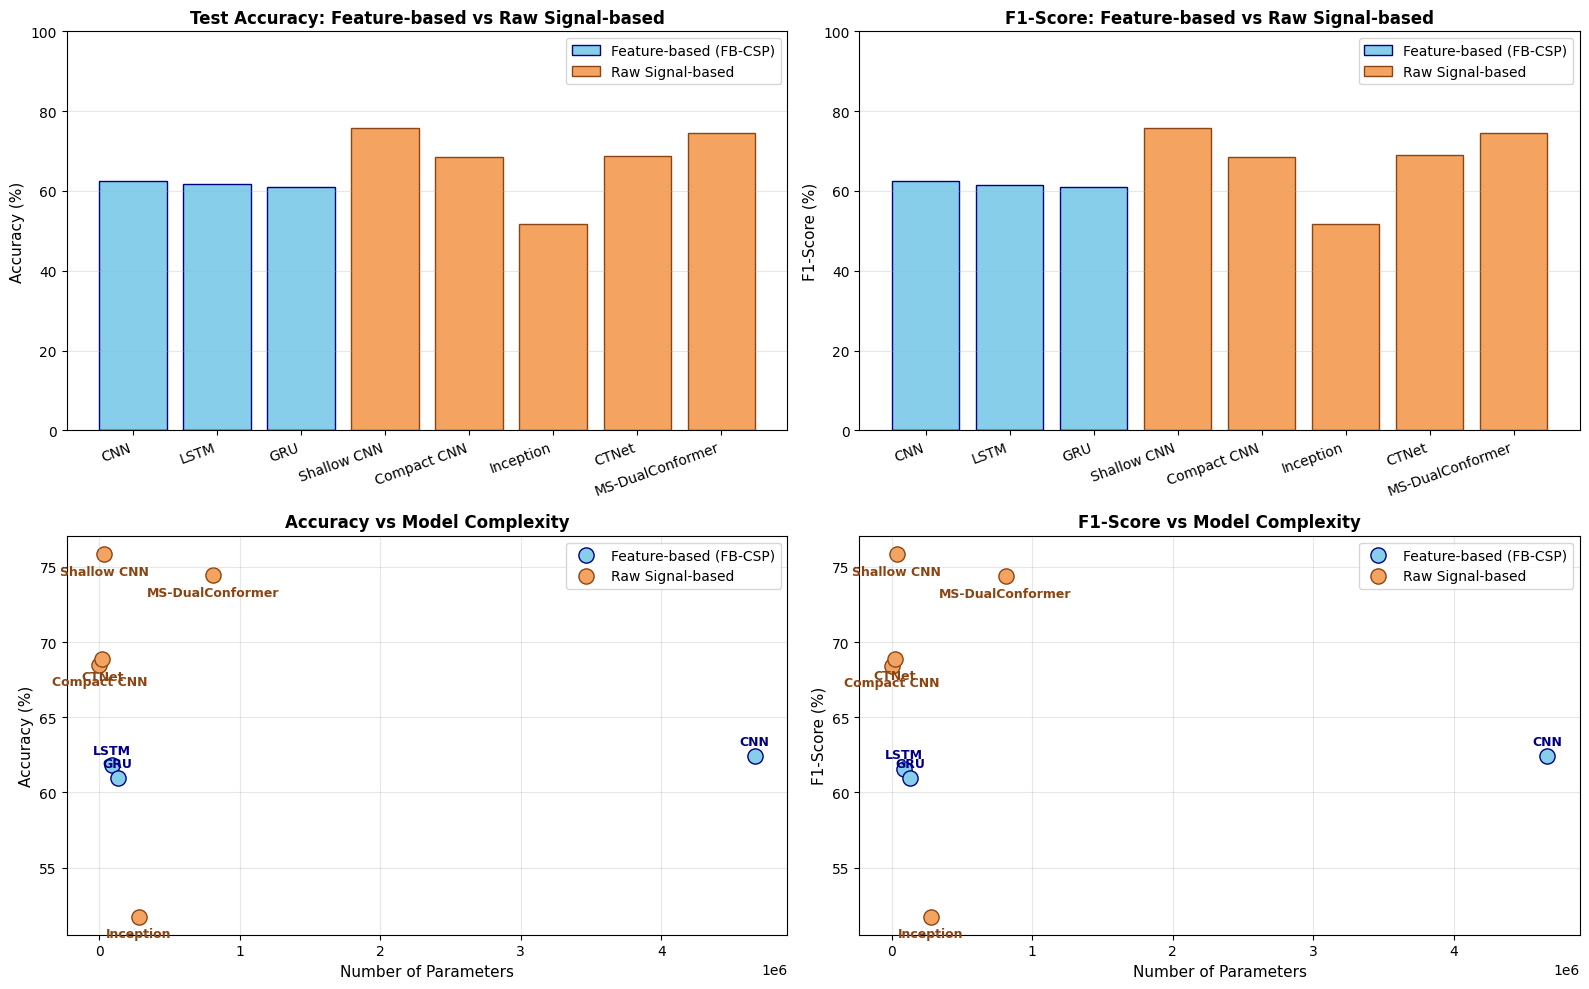

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  experiments = [
                'CNN',
                'LSTM',
                'GRU',
                'Shallow CNN',
                'Compact CNN',
                'Inception',
                #'EEGConformer', #It has an erratic weird behaviour for now lets not use it, future work
                'CTNet',
                'MS-DualConformer'
              ]
  y_true_labels = np.argmax(y_test, axis=1)

  # --- Calculate Metrics ---
  feat_metrics_acc = [
      accuracy_score(y_true_labels, y_pred_cnn) * 100,
      accuracy_score(y_true_labels, y_pred_lstm) * 100,
      accuracy_score(y_true_labels, y_pred_gru) * 100,
      0, 0, 0, 0, 0,
  ]

  raw_metrics_acc = [
      0, 0, 0,
      accuracy_score(y_true_labels, y_pred_shallow) * 100,
      accuracy_score(y_true_labels, y_pred_eegnet) * 100,
      accuracy_score(y_true_labels, y_pred_inception) * 100,
      #accuracy_score(y_true_labels, y_pred_eegconformer) * 100,
      accuracy_score(y_true_labels, y_pred_ctnet) * 100,
      accuracy_score(y_true_labels, y_pred_ms_dual_conformer) * 100,
  ]

  feat_metrics_f1 = [
      f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
      0, 0, 0, 0, 0,
  ]

  raw_metrics_f1 = [
      0, 0, 0,
      f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_eegnet, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
      #f1_score(y_true_labels, y_pred_eegconformer, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_ctnet, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_ms_dual_conformer, average='weighted') * 100,
  ]

  feat_weights = [
      cnn.count_params(),
      lstm.count_params(),
      gru.count_params(),
      0, 0, 0, 0, 0,
  ]

  raw_weights = [
      0, 0, 0,
      shallow.count_params(),
      eegnet.count_params(),
      inception.count_params(),
      #eegconformer.count_params(),
      ctnet.count_params(),
      ms_dual_conformer.count_params(),
  ]

  # --- Plotting ---
  x = np.arange(len(experiments))
  fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

  ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
  ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
  ax1.set_ylabel('Accuracy (%)', fontsize=11)
  ax1.set_title('Test Accuracy: Feature-based vs Raw Signal-based', fontsize=12, fontweight='bold')
  ax1.set_xticks(x)
  ax1.set_xticklabels(experiments, rotation=20, ha='right')
  ax1.set_ylim(0, 100)
  ax1.legend()
  ax1.grid(axis='y', alpha=0.3)

  ax2.bar(x, feat_metrics_f1, color='skyblue', label='Feature-based (FB-CSP)', edgecolor='navy')
  ax2.bar(x, raw_metrics_f1, color='sandybrown', label='Raw Signal-based', edgecolor='saddlebrown')
  ax2.set_ylabel('F1-Score (%)', fontsize=11)
  ax2.set_title('F1-Score: Feature-based vs Raw Signal-based', fontsize=12, fontweight='bold')
  ax2.set_xticks(x)
  ax2.set_xticklabels(experiments, rotation=20, ha='right')
  ax2.set_ylim(0, 100)
  ax2.legend()
  ax2.grid(axis='y', alpha=0.3)

  feat_indices = [i for i, w in enumerate(feat_weights) if w > 0]
  raw_indices  = [i for i, w in enumerate(raw_weights) if w > 0]

  ax3.scatter([feat_weights[i] for i in feat_indices],
              [feat_metrics_acc[i] for i in feat_indices],
              label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=120)
  ax3.scatter([raw_weights[i] for i in raw_indices],
              [raw_metrics_acc[i] for i in raw_indices],
              label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=120)
  for i in feat_indices:
      ax3.annotate(experiments[i], (feat_weights[i], feat_metrics_acc[i]),
                  textcoords="offset points", xytext=(0, 8),
                  ha='center', fontsize=9, color='navy', fontweight='bold')
  for i in raw_indices:
      ax3.annotate(experiments[i], (raw_weights[i], raw_metrics_acc[i]),
                  textcoords="offset points", xytext=(0, -15),
                  ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
  ax3.set_ylabel('Accuracy (%)', fontsize=11)
  ax3.set_xlabel('Number of Parameters', fontsize=11)
  ax3.set_title('Accuracy vs Model Complexity', fontsize=12, fontweight='bold')
  ax3.legend()
  ax3.grid(alpha=0.3)

  ax4.scatter([feat_weights[i] for i in feat_indices],
              [feat_metrics_f1[i] for i in feat_indices],
              label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=120)
  ax4.scatter([raw_weights[i] for i in raw_indices],
              [raw_metrics_f1[i] for i in raw_indices],
              label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=120)
  for i in feat_indices:
      ax4.annotate(experiments[i], (feat_weights[i], feat_metrics_f1[i]),
                  textcoords="offset points", xytext=(0, 8),
                  ha='center', fontsize=9, color='navy', fontweight='bold')
  for i in raw_indices:
      ax4.annotate(experiments[i], (raw_weights[i], raw_metrics_f1[i]),
                  textcoords="offset points", xytext=(0, -15),
                  ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
  ax4.set_ylabel('F1-Score (%)', fontsize=11)
  ax4.set_xlabel('Number of Parameters', fontsize=11)
  ax4.set_title('F1-Score vs Model Complexity', fontsize=12, fontweight='bold')
  ax4.legend()
  ax4.grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

## 5. Hyperparameter Optimization (FUTURE WORK, TODO)

In this section, hyperparameter optimization of the neural networks is explored. Although this is typically implemented with simple methods as out of the box 3-fold cross-validation. However our data is composed of multiple subjects and sessions (usally 2 sessions per subject in BCI competition), then training and testing in subject A will give inflated accuracy (subject leakage) and training and testing on session 1 will make temporal leakage.

To avoid leakage we must split taking those 2 concepts into account, but also if we want to tune hyperparameters in addition to only evaluation we need to split the data into train/val/test (70/20/10 for example) an perform 2 cross-validations:
- Inner CV: Hyperparameter Tuning (Val data)
- Outer CV: Evaluation (Test data)

There are 3 strategies we can implement with augmenting levels of complexity: (First one is simple train, test, second allows for evaluation CV, and third one evaluation CV + Hyperparameter optimization CV)

1. **Subject-grouped, session-wise split:**  

   Entire recording sessions for a subject are kept together. Train on one session and test on the other to prevent **temporal/session leakage**.  
    *Example:*  

    | Subject | Train Session | Test Session |
    |---------|---------------|--------------|
    | A       | A1             | A2            |
    | B       | B1             | B2            |
    | C       | C1             | C2            |
    | D       | D1             | D2            |


2. **Leave-One-Subject-Out (LOSO): (Evaluation CV):**
    
    One subject is completely held out for testing, while all other subjects are used for training. This prevents **subject leakage** and provides a realistic estimate of **cross-subject generalization**.  
    *Example:*  

    | Fold | Train Subjects | Test Subject |
    |------------|----------------|--------------|
    | 1          | B, C, D        | A            |
    | 2          | A, C, D        | B            |
    | 3          | A, B, D        | C            |
    | 4          | A, B, C        | D            |


3. **Nested, group-aware cross-validation: (Evaluation CV + HyperparamOPT CV)**
    
    **Outer CV**: evaluate final model on a held-out subject  **Inner CV**: split sessions within training data for hyperparameter tuning  
    *Example:*  

    | Fold | Outer Test Subject | Inner Train Sessions         | Inner Validation Sessions   |
    |------------|-----------------|------------------------------|----------------------------|
    | 1          | A               | B1, C1, D1                  | B2, C2, D2                 |
    | 2          | B               | A1, C1, D1                  | A2, C2, D2                 |
    | 3          | C               | A1, B1, D1                  | A2, B2, D2                 |
    | 4          | D               | A1, B1, C1                  | A2, B2, C2                 |




---
In the case of wanting to use Tree-Parzen or Gaussian Process optimization (Optuna), we could insert it in the Inner CV loop of the nested group aware cross validation, on validation data to prevent test leakeage.

**OBVIOUS NOTE:** Only perform this expensive procedures in promising architectures

In [ ]:
# TODO :)

In [ ]:
# DO A BIG CLEANUP OF USELESS VARIABLES TO THIS POINT
def free_memory():
  # List all variables to potentially delete
  variables_to_delete = [
      'n_train_cnn', 'height_cnn', 'width_cnn', 'n_val_cnn', 'n_test_cnn', 'scaler_cnn',
      'X_train_cnn_flat', 'X_train_cnn_scaled', 'X_val_cnn_flat', 'X_val_cnn_scaled',
      'X_test_cnn_flat', 'X_test_cnn_scaled', 'X_train_features_rnn', 'X_test_features_rnn', 'X_val_features_rnn',

      'n_train_rnn', 'n_steps_rnn', 'n_features_rnn', 'n_val_rnn', 'n_test_rnn', 'scaler_rnn',
      'X_train_rnn_flat', 'X_train_rnn_scaled', 'X_val_rnn_flat', 'X_val_rnn_scaled',
      'X_test_rnn_flat', 'X_test_rnn_scaled', 'X_train_features_cnn', 'X_test_features_cnn', 'X_val_features_cnn',

      'X_test_rnn', 'X_val_rnn', 'X_train_rnn',
      'X_train_cnn', 'X_val_cnn', 'X_test_cnn',

      'X_tmp', 'X_temp', 'y_tmp', 'y_temp', 'all_y', 'all_X',
      'val_bands', 'test_bands', 'train_bands',

      'results'
  ]

  for var_name in variables_to_delete:
      if var_name in globals():
          del globals()[var_name]
  gc.collect()

if FREE_MEM_BEFORE_ABLATION:
  free_memory()

## 6. ABLATION TEST

In this section similar to other EEG publications, a brief ablation test on this deep learning data pipeline is conducted to compare our architecture to other state-of-the-art approaches. The hyperparameters choices such as attention heads, number of attention layers and the disabling or not of some layers are going to be explored in order to asess their contributions.

The ablation study aims to answer the following research questions (divided into 7 groups (G) or areas of research):

0. **G.A**: Are multiscale embeddings better than single scale (A1) ? Is there a significant difference in the frequency range covered by these multiscale filters?
1. **G.B**: Are both temporal and channel embeddings necessary, or does one dominate?
2. **G.C**: Does cross-attention fusion provide additional gains over independent processing? Is it better to not use cross-attention at all?
3. **G.D**: What is the optimal pooling strategy for aggregating dual-axis representations?
4. **G.E**: How sensitive is the model to the number of attention layers and heads?
5. **G.F**: Does positional encoding improve performance for EEG signals?
6. **G.G**: How does the embedding dimensionality affect performance? Which is a clear bottleneck size?


In [ ]:
class ExperimentConfig:
    """Structured configuration for ablation experiments"""
    def __init__(self,
                 exp_id: str,
                 group: str,
                 description: str,
                 model_params: Dict[str, Any],
                 training_config: Dict[str, Any] = config):
        self.exp_id = exp_id
        self.group = group
        self.description = description
        self.model_params = model_params
        self.timestamp = None
        self.results = {}
        self.training_config = training_config

    def to_dict(self):
        return {
            'exp_id': self.exp_id,
            'group': self.group,
            'description': self.description,
            'model_params': self.model_params,
            'timestamp': self.timestamp,
            'results': self.results,
            'training_config': self.training_config
        }

    @classmethod
    def from_dict(cls, data):
        config = cls(
            data['exp_id'],
            data['group'],
            data['description'],
            data['model_params'],
            data.get('training_config', {})
        )
        config.timestamp = data.get('timestamp')
        config.results = data.get('results', {})
        return config

    def __repr__(self):
        return f"ExperimentConfig({self.exp_id}, group: {self.group}: {self.description})"

# Create results directory
RESULTS_DIR = Path('./ablation_results')
RESULTS_DIR.mkdir(exist_ok=True)


############################# EXPERIMENTS MANAGEMENT ############################

def save_experiment_result(config: ExperimentConfig, results: Dict[str, Any]):
    """Save individual experiment results to JSON"""
    config.results = results
    config.timestamp = datetime.now().isoformat()

    filepath = RESULTS_DIR / f"{config.exp_id}.json"
    with open(filepath, 'w') as f:
        json.dump(config.to_dict(), f, indent=2)

    logger.info(f"Saved results for {config.exp_id} to {filepath}")

def load_experiment_result(exp_id: str) -> ExperimentConfig:
    """Load experiment results from JSON"""
    filepath = RESULTS_DIR / f"{exp_id}.json"
    if not filepath.exists():
        raise FileNotFoundError(f"No results found for {exp_id}")

    with open(filepath, 'r') as f:
        data = json.load(f)

    return ExperimentConfig.from_dict(data)

def load_all_results() -> Dict[str, List[ExperimentConfig]]:
    """Load all experiment results organized by group"""
    results = defaultdict(list)

    for filepath in sorted(RESULTS_DIR.glob("*.json")):
        with open(filepath, 'r') as f:
            data = json.load(f)

        config = ExperimentConfig.from_dict(data)
        results[config.group].append(config)

    return dict(results)

############################# TRAINING/RUNNING MANAGEMENT ############################

def train_experiment(
    config: ExperimentConfig,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    base_model_params: Dict[str, Any],
    force_retrain: bool = False
) -> Dict[str, Any]:
    """Train and evaluate a single experiment"""

    # Check if results already exist
    if not force_retrain:
        try:
            existing = load_experiment_result(config.exp_id)
            if existing.results:
                logger.info(f"Loading cached results for {config.exp_id}")
                return existing.results
        except FileNotFoundError:
            pass

    logger.info(f"Training {config.exp_id}: {config.description}")

    # Merge base params with experiment-specific params
    model_params = {**base_model_params, **config.model_params}

    # Build model
    model = m.MultiScaleDualAxisConformer(
        nb_classes=N, Chans=C, Samples=T,
        **model_params
    )

    learning_rate = config.training_config.get('lr', 1e-4)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', f1_score_metric]
    )

    # Early stopping and checkpointing
    checkpoint_path = RESULTS_DIR / f"{config.exp_id}_best.h5"
    callbacks = [
        EarlyStopping(monitor='val_f1_score_metric', mode='max',
                      patience=config.training_config.get('patience', 3), restore_best_weights=True),
        ModelCheckpoint(str(checkpoint_path), monitor='val_f1_score_metric',
                        mode='max', save_best_only=True)
    ]

    batch_size = config.training_config.get('batch_size', 32)
    epochs = config.training_config.get('epochs', 10)

    # Train
    start_time = datetime.now()
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    training_time = (datetime.now() - start_time).total_seconds()

    # Clean up callbacks
    del callbacks
    gc.collect()

    # Evaluate on train
    train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    train_true = np.argmax(y_train, axis=1)
    train_acc = float(accuracy_score(train_true, train_pred))
    train_f1 = float(f1_score(train_true, train_pred, average='weighted'))

    # Clean up train predictions immediately
    del train_pred, train_true
    gc.collect()

    # Evaluate on val
    val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    val_true = np.argmax(y_val, axis=1)
    val_acc = float(accuracy_score(val_true, val_pred))
    val_f1 = float(f1_score(val_true, val_pred, average='weighted'))

    # Clean up val predictions immediately
    del val_pred, val_true
    gc.collect()

    # Evaluate on test
    test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_true = np.argmax(y_test, axis=1)
    test_acc = float(accuracy_score(test_true, test_pred))
    test_f1 = float(f1_score(test_true, test_pred, average='weighted'))
    cm = confusion_matrix(test_true, test_pred).tolist()

    # Clean up test predictions
    del test_pred, test_true
    gc.collect()

    # Extract history values
    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])
    best_epoch = int(np.argmax(history.history['val_f1_score_metric'])) + 1
    num_params = int(model.count_params())

    # Clean up history
    del history
    gc.collect()

    results = {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'num_params': num_params,
        'training_time_seconds': float(training_time),
        'best_epoch': best_epoch,
        'confusion_matrix': cm
    }

    # Save results
    save_experiment_result(config, results)

    # Final cleanup - destroy model completely
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return results


def run_experiments(
    experiments: List[ExperimentConfig],
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    base_model_params: Dict[str, Any],
    force_retrain: bool = False
):
    """Run a list of experiments"""

    group_name = experiments[0].group if experiments else "Unknown"
    logger.info(f"Running {len(experiments)} experiments in Group {group_name}")

    for idx, config in enumerate(tqdm(experiments, desc=f"Group {group_name}")):
        try:
            results = train_experiment(
                config, X_train, y_train, X_val, y_val, X_test, y_test,
                base_model_params, force_retrain
            )

            logger.info(f"{config.exp_id}: Test Acc={results['test_acc']:.4f}, "
                       f"Test F1={results['test_f1']:.4f}, "
                       f"Params={results['num_params']:,}")

            # Cleanup after each experiment
            del results
            gc.collect()

            # Extra aggressive cleanup every 3 experiments
            if (idx + 1) % 3 == 0:
                tf.keras.backend.clear_session()
                gc.collect()

        except Exception as e:
            logger.error(f"Failed to run {config.exp_id}: {str(e)}")
            # Cleanup even on failure
            tf.keras.backend.clear_session()
            gc.collect()
            continue


############################# PLOTTING AND DISPLAYING ############################

def plot_group_results(group_name: str, metric: str = 'test_acc'):
    """Plot comparison of experiments within a group, showing ID + description"""

    all_results = load_all_results()
    if group_name not in all_results:
        logger.warning(f"No results found for group {group_name}")
        return

    configs = all_results[group_name]

    # Extract data
    labels = []
    values = []

    for config in configs:
        if config.results and metric in config.results:
            labels.append(f"{config.exp_id}: {config.description}")
            values.append(config.results[metric] * 100)

    if not values:
        logger.warning(f"No metric data found for {group_name}")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(labels)), values, color='steelblue', edgecolor='navy', alpha=0.7)

    # Highlight best
    best_idx = np.argmax(values)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('darkorange')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric.replace("_", " ").title()} (%)')
    ax.set_title(f'Group {group_name}: {metric.replace("_", " ").title()}')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}%',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'group_{group_name}_{metric}.png', dpi=300)
    plt.show()

    # Cleanup plot
    plt.close(fig)
    del fig, ax, bars, labels, values
    gc.collect()


def plot_all_groups(metric: str = 'test_acc'):
    """Plot summary across all groups, showing ID + description"""

    all_results = load_all_results()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, (group_name, configs) in enumerate(sorted(all_results.items())):
        if idx >= len(axes):
            break

        ax = axes[idx]

        labels = []
        values = []

        for config in configs:
            if config.results and metric in config.results:
                labels.append(f"{config.exp_id}: {config.description}")
                values.append(config.results[metric] * 100)

        if values:
            bars = ax.bar(range(len(labels)), values, color='steelblue', alpha=0.7)
            best_idx = np.argmax(values)
            bars[best_idx].set_color('gold')

            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
            ax.set_title(f'Group {group_name}', fontweight='bold')
            ax.set_ylabel(f'{metric} (%)')
            ax.grid(axis='y', alpha=0.3)

    # Hide unused subplots
    for idx in range(len(all_results), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Ablation Study Summary: {metric.replace("_", " ").title()}',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'all_groups_{metric}.png', dpi=300)
    plt.show()

    # Cleanup plot
    plt.close(fig)
    del fig, axes, all_results
    gc.collect()


def save_results_summary():
    """Save CSV summary of all results"""

    all_results = load_all_results()

    rows = []
    for group_name, configs in all_results.items():
        for config in configs:
            if config.results:
                row = {
                    'exp_id': config.exp_id,
                    'group': config.group,
                    'description': config.description,
                    'timestamp': config.timestamp,
                    **config.results
                }
                rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / 'ablation_summary.csv', index=False)
    logger.info(f"Saved summary to {RESULTS_DIR / 'ablation_summary.csv'}")

    # Cleanup
    del all_results, rows
    gc.collect()

    return df


In [ ]:
# These willm be used as the baseline parameters (No reason in particular though)

# Lets pray to god that Samples is not a prime number :)
patch_pool_size = next(k for k in range(8, 2, -1) if T % k == 0)
print(f"Patch pool size: {patch_pool_size}")

baseline_params = {
    'emb_size': 40,
    'patch_pool_size': patch_pool_size,
    'patch_channel_temp_filter_size': 4,
    'patch_kernel_sizes': (5, 12, 25, 64, 125),
    'patch_filters_per_scale': (8, 16, 16, 16, 8),

    'pe_droprate': 0.1,

    'att_num_layers': 2,
    'att_num_heads': 4,
    'att_dropout': 0.15,

    'fusion_mode': "gap+flatten",
    'pool_droprate': 0.5,
    'classif_hidden_units': (128, 32),
    'classif_droprate_probs': (0.4, 0.3),
}

Patch pool size: 3


### 6.1 ABLATION GROUP A : MultiScale Patch Embeddings Analysis

This experiment investigates the contribution of multi-scale temporal convolutions for capturing different EEG frequency bands, a key innovation of our architecture over baseline models.

**A.1: Single-Scale vs Multi-Scale Comparison**

 Determine if multi-scale convolutions provide gains over single-scale baselines with matched parameter count.

| Exp ID | Kernel Sizes | Filters per Scale | Total Filters | Coverage |
|--------|-------------|-------------------|---------------|----------|
| A1a | `(25,)` | `(60,)` | 60 | Single-scale (alpha band ~10Hz) |
| A1b | `(64,)` | `(60,)` | 60 | Single-scale (theta band ~4Hz) |
| A1c | `(5, 25, 125)` | `(20, 20, 20)` | 60 | 3-scale (gamma, alpha, delta) |
| A1d | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | 60 | **5-scale balanced (baseline)** |

---

**A.2: Kernel Size Coverage**

Testing if kernel sizes aligned with neurophysiological frequency bands improve performance (Frequency Band Hypothesis, the whole premise under the inductive bias of these complex patch embeddings).

| Exp ID | Kernel Sizes | Filters per Scale | Frequency Coverage |
|--------|-------------|-------------------|-------------------|
| A2a | `(3, 7, 15, 31, 63, 125)` | `(6, 8, 12, 12, 12, 10)` | **Full spectrum** (100Hz → 2Hz) |
| A2b | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | **Baseline** (missing theta gap) |
| A2c | `(7, 15, 31, 63)` | `(15, 15, 15, 15)` | **Mid-range only** (beta-alpha-theta) |
| A2d | `(3, 7, 15)` | `(20, 20, 20)` | **High-frequency only** (gamma-beta) |
| A2e | `(31, 63, 125)` | `(20, 20, 20)` | **Low-frequency only** (alpha-theta-delta) |

**REMINDER!: At Fs=250Hz**:
- 3 samples = 83Hz (high gamma)
- 7 samples = 36Hz (beta)
- 15 samples = 17Hz (beta)
- 31 samples = 8Hz (alpha)
- 63 samples = 4Hz (theta)
- 125 samples = 2Hz (delta)

**Expected Outcome**: A2a ≥ A2b > A2c, A2d, A2e. Full spectrum coverage performs best, with task-specific bands (A2c/d/e) showing varying importance depending on the EEG task (e.g., motor imagery may favor A2c, sleep staging may favor A2e).


In [ ]:

# A.1: Single vs Multi-scale
experiments_A1 = [
    ExperimentConfig(
        exp_id='A1a',
        group='A1',
        description='Single-scale alpha band (~10Hz)',
        model_params={
            'patch_kernel_sizes': (25,),
            'patch_filters_per_scale': (60,),
        }
    ),
    ExperimentConfig(
        exp_id='A1b',
        group='A1',
        description='Single-scale theta band (~4Hz)',
        model_params={
            'patch_kernel_sizes': (64,),
            'patch_filters_per_scale': (60,),
        }
    ),
    ExperimentConfig(
        exp_id='A1c',
        group='A1',
        description='3-scale (gamma, alpha, delta)',
        model_params={
            'patch_kernel_sizes': (5, 25, 125),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
    ExperimentConfig(
        exp_id='A1d',
        group='A1',
        description='5-scale balanced',
        model_params={
            'patch_kernel_sizes': (5, 12, 25, 64, 125),
            'patch_filters_per_scale': (12, 12, 12, 12, 12),
        }
    )
]
experiments_A2 = [
    ExperimentConfig(
        exp_id='A2a',
        group='A2',
        description='Full spectrum coverage (100Hz → 2Hz)',
        model_params={
            'patch_kernel_sizes': (3, 7, 15, 31, 63, 125),
            'patch_filters_per_scale': (6, 8, 12, 12, 12, 10),
        }
    ),
    ExperimentConfig(
        exp_id='A2b',
        group='A2',
        description='Standard 5-scale (missing theta gap)',
        model_params={
            'patch_kernel_sizes': (5, 12, 25, 64, 125),
            'patch_filters_per_scale': (12, 12, 12, 12, 12),
        }
    ),
    ExperimentConfig(
        exp_id='A2c',
        group='A2',
        description='Mid-range only (beta-alpha-theta)',
        model_params={
            'patch_kernel_sizes': (7, 15, 31, 63),
            'patch_filters_per_scale': (15, 15, 15, 15),
        }
    ),
    ExperimentConfig(
        exp_id='A2d',
        group='A2',
        description='High-frequency only (gamma-beta)',
        model_params={
            'patch_kernel_sizes': (3, 7, 15),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
    ExperimentConfig(
        exp_id='A2e',
        group='A2',
        description='Low-frequency only (alpha-theta-delta)',
        model_params={
            'patch_kernel_sizes': (31, 63, 125),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
]



2026-01-25 09:14:39.944 | INFO     | __main__:run_experiments:234 - Running 4 experiments in Group A1


Group A1:   0%|          | 0/4 [00:00<?, ?it/s]

2026-01-25 09:14:40.674 | INFO     | __main__:train_experiment:103 - Loading cached results for A1a
2026-01-25 09:14:40.674 | INFO     | __main__:run_experiments:243 - A1a: Test Acc=0.7833, Test F1=0.7833, Params=833,775
2026-01-25 09:14:42.653 | INFO     | __main__:train_experiment:103 - Loading cached results for A1b
2026-01-25 09:14:42.654 | INFO     | __main__:run_experiments:243 - A1b: Test Acc=0.7863, Test F1=0.7859, Params=836,115
2026-01-25 09:14:44.736 | INFO     | __main__:train_experiment:103 - Loading cached results for A1c
2026-01-25 09:14:44.737 | INFO     | __main__:run_experiments:243 - A1c: Test Acc=0.7751, Test F1=0.7751, Params=835,375
2026-01-25 09:14:49.210 | INFO     | __main__:train_experiment:103 - Loading cached results for A1d
2026-01-25 09:14:49.211 | INFO     | __main__:run_experiments:243 - A1d: Test Acc=0.7729, Test F1=0.7729, Params=835,047


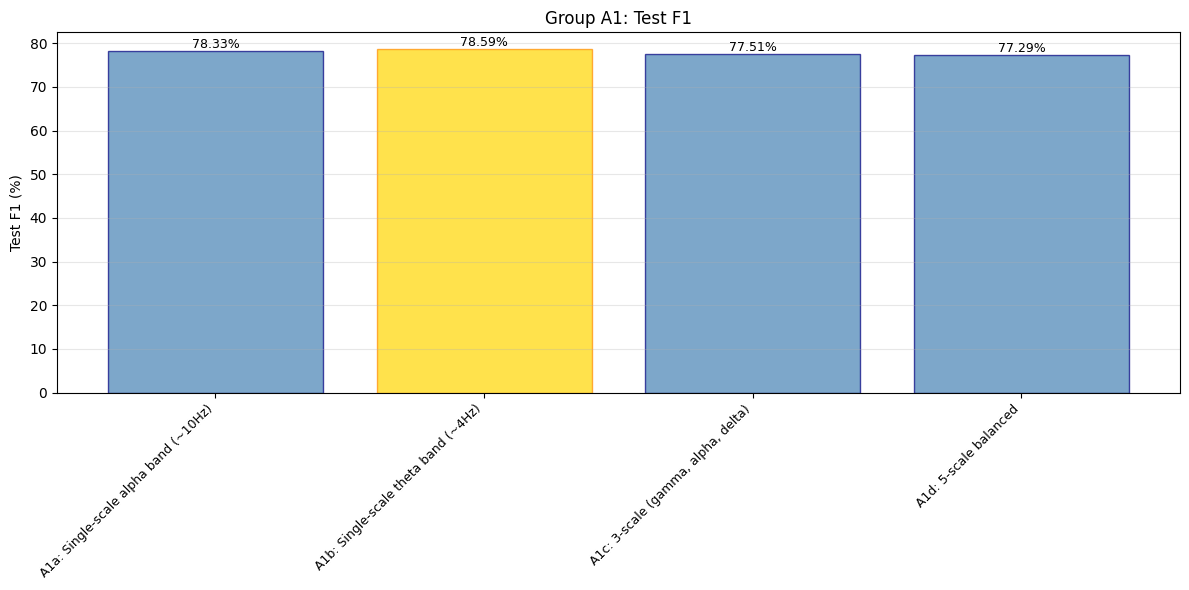

In [ ]:
run_experiments(
    experiments_A1,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["A1"]
)
plot_group_results('A1', metric='test_f1')

2026-01-25 09:15:19.298 | INFO     | __main__:run_experiments:234 - Running 5 experiments in Group A2


Group A2:   0%|          | 0/5 [00:00<?, ?it/s]

2026-01-25 09:15:19.309 | INFO     | __main__:train_experiment:103 - Loading cached results for A2a
2026-01-25 09:15:19.309 | INFO     | __main__:run_experiments:243 - A2a: Test Acc=0.7796, Test F1=0.7799, Params=834,907
2026-01-25 09:15:20.475 | INFO     | __main__:train_experiment:103 - Loading cached results for A2b
2026-01-25 09:15:20.476 | INFO     | __main__:run_experiments:243 - A2b: Test Acc=0.7736, Test F1=0.7741, Params=835,047
2026-01-25 09:15:21.597 | INFO     | __main__:train_experiment:103 - Loading cached results for A2c
2026-01-25 09:15:21.597 | INFO     | __main__:run_experiments:243 - A2c: Test Acc=0.7848, Test F1=0.7847, Params=834,015
2026-01-25 09:15:24.970 | INFO     | __main__:train_experiment:103 - Loading cached results for A2d
2026-01-25 09:15:24.970 | INFO     | __main__:run_experiments:243 - A2d: Test Acc=0.7878, Test F1=0.7879, Params=832,775
2026-01-25 09:15:26.090 | INFO     | __main__:train_experiment:103 - Loading cached results for A2e
2026-01-25 09:15

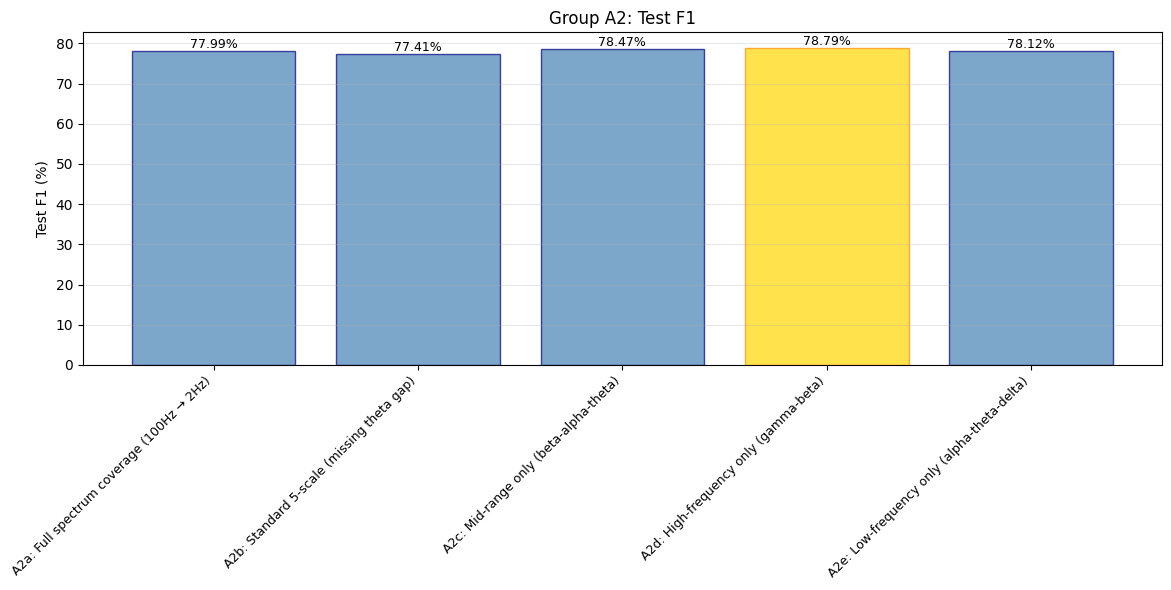

In [ ]:
run_experiments(
    experiments_A2,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["A2"]
)
plot_group_results('A2', metric='test_f1')

### ABLATION GROUP B: Embeddings

Hypothesis: Both are important, but time >>> channel in importance, also the Expected Outcome we foresee is:  B3 > B1 > B2, demonstrating that both token types contribute.


| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| B1 | `use_time_embeddings=True, use_channel_embeddings=False` | Time tokens only |
| B2 | `use_time_embeddings=False, use_channel_embeddings=True` | Channel tokens only |
| B3 | `use_time_embeddings=True, use_channel_embeddings=True, use_cross_attention=True` | **Full model (baseline)** |

In [ ]:
experiments_B = [
    ExperimentConfig(
        exp_id='B1',
        group='B',
        description='Time tokens only',
        model_params={
            'use_time_embeddings': True,
            'use_channel_embeddings': False,
        },
    ),
    ExperimentConfig(
        exp_id='B2',
        group='B',
        description='Channel tokens only',
        model_params={
            'use_time_embeddings': False,
            'use_channel_embeddings': True,
        }
    ),
    ExperimentConfig(
        exp_id='B3',
        group='B',
        description='Full model (both embeddings)',
        model_params={
            'use_time_embeddings': True,
            'use_channel_embeddings': True,
        }
    )
]

2026-01-25 09:15:29.932 | INFO     | __main__:run_experiments:234 - Running 3 experiments in Group B


Group B:   0%|          | 0/3 [00:00<?, ?it/s]

2026-01-25 09:15:29.943 | INFO     | __main__:train_experiment:103 - Loading cached results for B1
2026-01-25 09:15:29.943 | INFO     | __main__:run_experiments:243 - B1: Test Acc=0.7759, Test F1=0.7759, Params=439,899
2026-01-25 09:15:31.084 | INFO     | __main__:train_experiment:103 - Loading cached results for B2
2026-01-25 09:15:31.084 | INFO     | __main__:run_experiments:243 - B2: Test Acc=0.7135, Test F1=0.7077, Params=387,247
2026-01-25 09:15:32.226 | INFO     | __main__:train_experiment:103 - Loading cached results for B3
2026-01-25 09:15:32.226 | INFO     | __main__:run_experiments:243 - B3: Test Acc=0.8333, Test F1=0.8334, Params=878,735


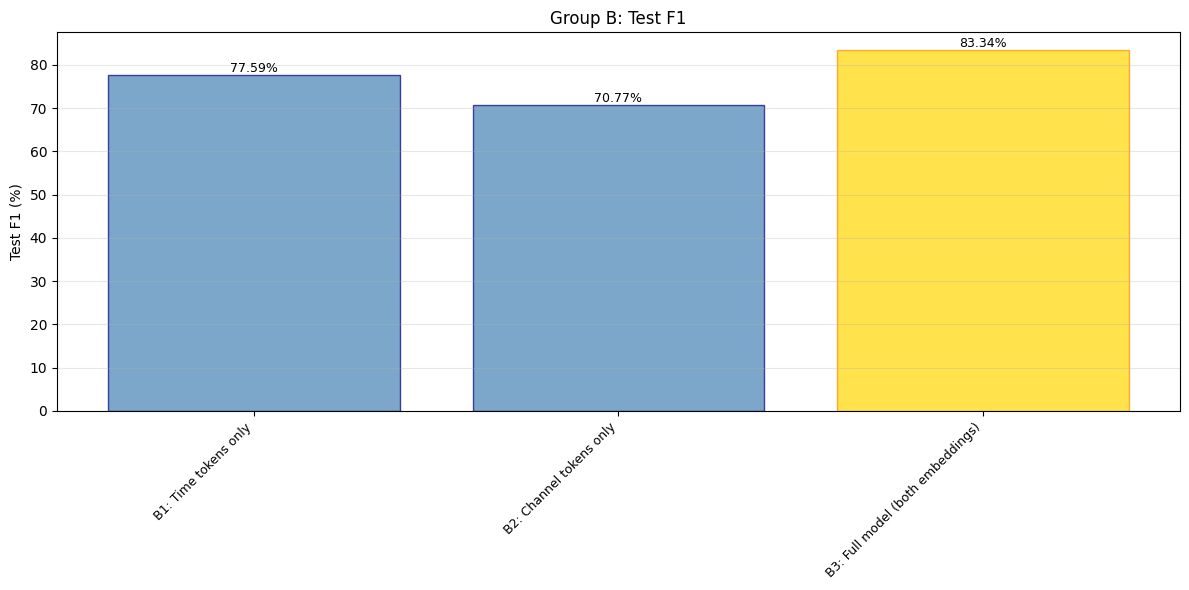

In [ ]:
run_experiments(
    experiments_B,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["B"]
)
plot_group_results('B', metric='test_f1')

### ABLATION GROUP C: Cross-Attention Strategy
Hypothesis: Unidirectional cross-attention may be sufficient, the expected outcome we forsee is: C4 ≥ C2 > C3 > C1, showing bidirectional fusion is optimal, with time-to-channel being the more important direction.


 Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| C1 | `use_cross_time_attention=False, use_cross_channel_attention=False` | No cross-attention at all |
| C2 | `use_cross_time_attention=True, use_cross_channel_attention=False` | Unidirectional: Time→Channel |
| C3 | `use_cross_time_attention=False, use_cross_channel_attention=True` | Unidirectional: Channel→Time |
| C4 | `use_cross_time_attention=True, use_cross_channel_attention=True` | **Bidirectional (full)** |


In [ ]:
experiments_C = [
    ExperimentConfig(
        exp_id='C1',
        group='C',
        description='No cross-attention',
        model_params={
            'use_cross_time_attention': False,
            'use_cross_channel_attention': False,
        }
    ),
    ExperimentConfig(
        exp_id='C2',
        group='C',
        description='Unidirectional: Time→Channel',
        model_params={
            'use_cross_time_attention': True,
            'use_cross_channel_attention': False,
        }
    ),
    ExperimentConfig(
        exp_id='C3',
        group='C',
        description='Unidirectional: Channel→Time',
        model_params={
            'use_cross_time_attention': False,
            'use_cross_channel_attention': True,
        }
    ),
    ExperimentConfig(
        exp_id='C4',
        group='C',
        description='Bidirectional (full)',
        model_params={
            'use_cross_time_attention': True,
            'use_cross_channel_attention': True,
        }
    ),
]

2026-01-25 09:15:38.226 | INFO     | __main__:run_experiments:234 - Running 4 experiments in Group C


Group C:   0%|          | 0/4 [00:00<?, ?it/s]

2026-01-25 09:15:38.238 | INFO     | __main__:train_experiment:103 - Loading cached results for C1
2026-01-25 09:15:38.238 | INFO     | __main__:run_experiments:243 - C1: Test Acc=0.8021, Test F1=0.8024, Params=810,127
2026-01-25 09:15:39.376 | INFO     | __main__:train_experiment:103 - Loading cached results for C2
2026-01-25 09:15:39.376 | INFO     | __main__:run_experiments:243 - C2: Test Acc=0.8333, Test F1=0.8335, Params=844,431
2026-01-25 09:15:40.508 | INFO     | __main__:train_experiment:103 - Loading cached results for C3
2026-01-25 09:15:40.509 | INFO     | __main__:run_experiments:243 - C3: Test Acc=0.8073, Test F1=0.8067, Params=844,431
2026-01-25 09:15:43.919 | INFO     | __main__:train_experiment:103 - Loading cached results for C4
2026-01-25 09:15:43.920 | INFO     | __main__:run_experiments:243 - C4: Test Acc=0.8125, Test F1=0.8124, Params=878,735


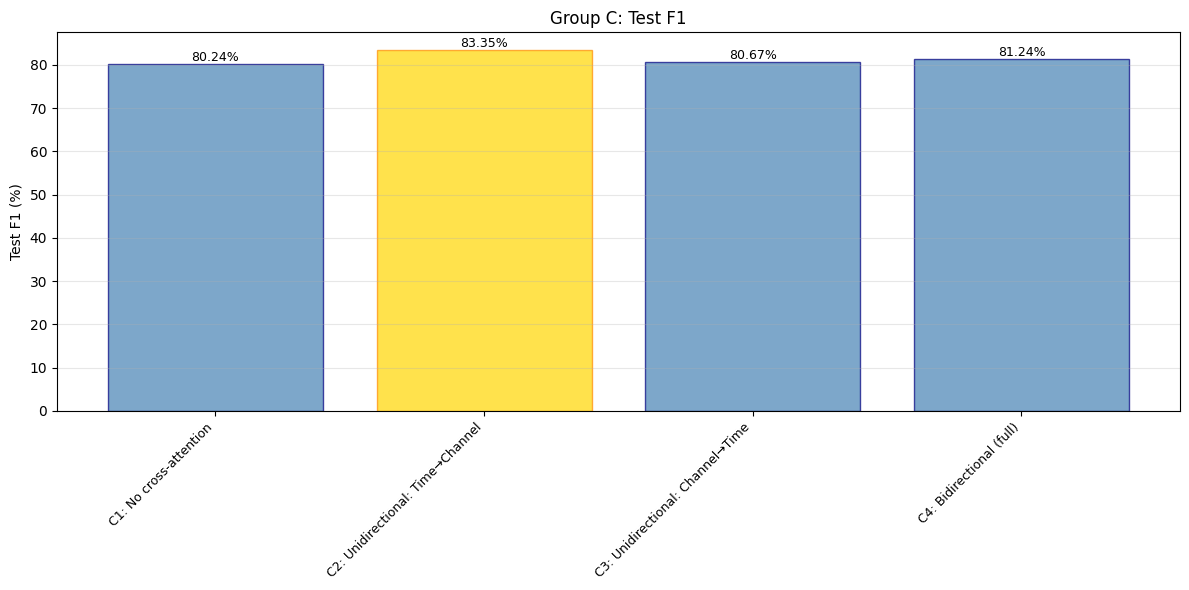

In [ ]:
run_experiments(
    experiments_C,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["C"]
)
plot_group_results('C', metric='test_f1')

### ABLATION GROUP D: Pooling Strategy
Hypothesis: "gap" alone may work better (less overfitting) and be sufficient in contrast to CTNet, with the following expected outcome:  D2 or D3 should perform best, as D1 may lead to overfitting due to high dimensionality.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| D1 | `fusion_mode="flatten"` | Preserve all spatial-temporal info |
| D2 | `fusion_mode="gap"` | Global average + max pooling only |
| D3 | `fusion_mode="gap+flatten"` | **Hybrid approach (full)** |



In [ ]:
experiments_D = [
    ExperimentConfig(
        exp_id='D1',
        group='D',
        description='Flatten only',
        model_params={'fusion_mode': 'flatten'},
    ),
    ExperimentConfig(
        exp_id='D2',
        group='D',
        description='GAP only',
        model_params={'fusion_mode': 'gap'},
    ),
    ExperimentConfig(
        exp_id='D3',
        group='D',
        description='Hybrid (GAP + flatten)',
        model_params={'fusion_mode': 'gap+flatten'},
    ),
]

2026-01-25 09:15:47.718 | INFO     | __main__:run_experiments:234 - Running 3 experiments in Group D


Group D:   0%|          | 0/3 [00:00<?, ?it/s]

2026-01-25 09:15:47.728 | INFO     | __main__:train_experiment:103 - Loading cached results for D1
2026-01-25 09:15:47.729 | INFO     | __main__:run_experiments:243 - D1: Test Acc=0.8385, Test F1=0.8386, Params=862,351
2026-01-25 09:15:48.858 | INFO     | __main__:train_experiment:103 - Loading cached results for D2
2026-01-25 09:15:48.858 | INFO     | __main__:run_experiments:243 - D2: Test Acc=0.7292, Test F1=0.7293, Params=559,247
2026-01-25 09:15:49.992 | INFO     | __main__:train_experiment:103 - Loading cached results for D3
2026-01-25 09:15:49.992 | INFO     | __main__:run_experiments:243 - D3: Test Acc=0.8073, Test F1=0.8064, Params=878,735


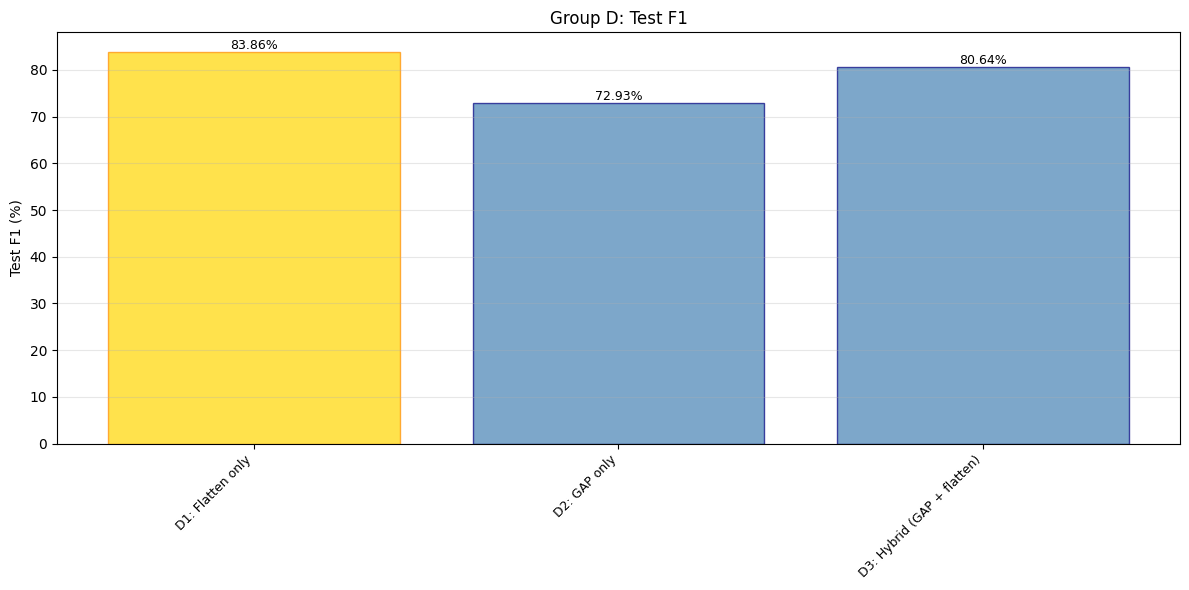

In [ ]:
run_experiments(
    experiments_D,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["D"]
)
plot_group_results('D', metric='test_f1')

### ABLATION GROUP E: Attention Layers Depth

This experiment investigates the optimal depth of the interleaved dual-axis transformer, testing whether deeper networks improve EEG representation learning or lead to diminishing returns.

| Exp ID | Num Layers | Time Self-Attn | Channel Self-Attn | Cross-Attn (per layer) | Total Attn Operations |
|--------|-----------|----------------|-------------------|----------------------|----------------------|
| E1 | 2 | 2 | 2 | 2 | 6 |
| E2 | 4 | 4 | 4 | 4 | **12 (baseline)** |
| E3 | 8 | 8 | 8 | 8 | 24 |
| E4 | 16 | 16 | 16 | 16 | 48 |
| E5 | 32 | 32 | 32 | 32 | 96 |


**Configuration**: All experiments use `num_heads=8` (fixed), `att_dropout=0.1`, and full cross-attention enabled (`use_cross_time_attention=True`, `use_cross_channel_attention=True`).

**Purpose**: Identify the point of diminishing returns for network depth in EEG processing, balancing representational capacity against computational cost and overfitting risk

---
We have solid points against trying varying number of heads! (Paper + makes no sense the embeddings being so small)


In [ ]:
experiments_E = [
    ExperimentConfig(
        exp_id='E1',
        group='E',
        description='2 layers (shallow)',
        model_params={
            'att_num_layers': 2,
        }
    ),
    ExperimentConfig(
        exp_id='E2',
        group='E',
        description='4 layers',
        model_params={
            'att_num_layers': 4,
        }
    ),
    ExperimentConfig(
        exp_id='E3',
        group='E',
        description='8 layers',
        model_params={
            'att_num_layers': 8,
        }
    ),
    ExperimentConfig(
        exp_id='E4',
        group='E',
        description='16 layers',
        model_params={
            'att_num_layers': 16,
            'att_num_layers': 16,
        }
    ),
    ExperimentConfig(
        exp_id='E5',
        group='E',
        description='32 layers',
        model_params={
            'att_num_layers': 32,
            'att_num_layers': 32,
        }
    ),
]

2026-01-25 09:15:55.881 | INFO     | __main__:run_experiments:234 - Running 5 experiments in Group E


Group E:   0%|          | 0/5 [00:00<?, ?it/s]

2026-01-25 09:15:55.892 | INFO     | __main__:train_experiment:103 - Loading cached results for E1
2026-01-25 09:15:55.893 | INFO     | __main__:run_experiments:243 - E1: Test Acc=0.8229, Test F1=0.8231, Params=674,831
2026-01-25 09:15:57.030 | INFO     | __main__:train_experiment:103 - Loading cached results for E2
2026-01-25 09:15:57.030 | INFO     | __main__:run_experiments:243 - E2: Test Acc=0.8177, Test F1=0.8174, Params=742,799
2026-01-25 09:15:58.159 | INFO     | __main__:train_experiment:103 - Loading cached results for E3
2026-01-25 09:15:58.160 | INFO     | __main__:run_experiments:243 - E3: Test Acc=0.7969, Test F1=0.7983, Params=878,735
2026-01-25 09:16:01.529 | INFO     | __main__:train_experiment:103 - Loading cached results for E4
2026-01-25 09:16:01.529 | INFO     | __main__:run_experiments:243 - E4: Test Acc=0.7865, Test F1=0.7851, Params=1,150,607
2026-01-25 09:16:02.661 | INFO     | __main__:train_experiment:103 - Loading cached results for E5
2026-01-25 09:16:02.662

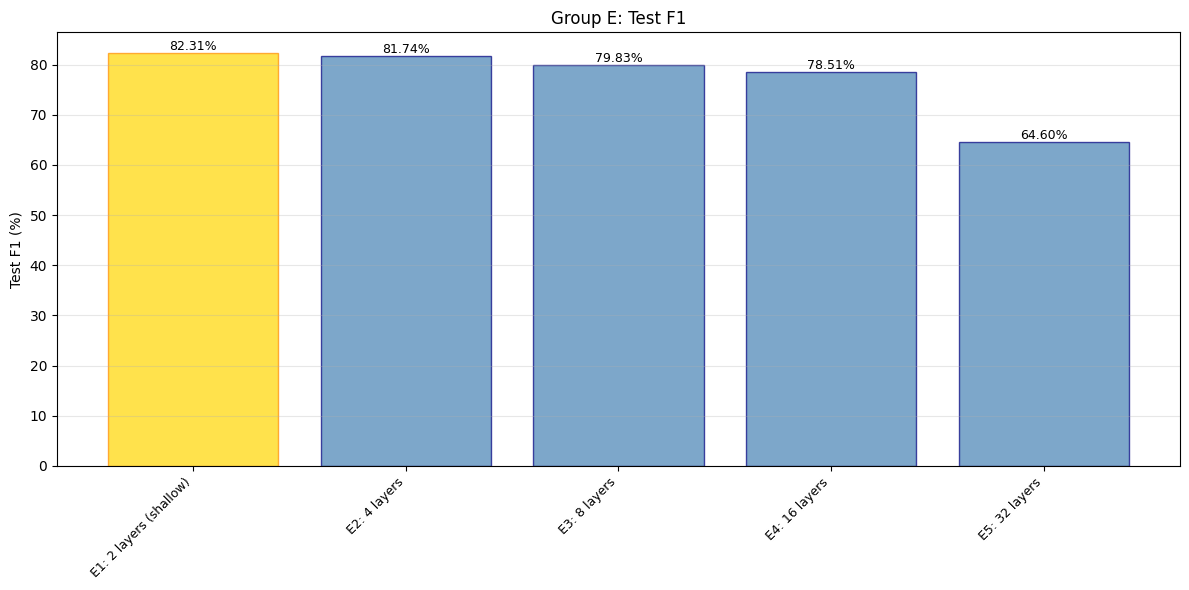

In [ ]:
run_experiments(
    experiments_E,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["E"]
)
plot_group_results('E', metric='test_f1')

### ABLATION GROUP F: Positional Encoding

Hypothesis: as temporal order matters in EEG signals, then it probably its the case that F2 > F1.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| F1 | `use_positional_encoding=False` | No positional encoding |
| F2 | `use_positional_encoding=True` | **With positional encoding (baseline)** |




In [ ]:
experiments_F = [
    ExperimentConfig(
        exp_id='F1',
        group='F',
        description='No positional encoding',
        model_params={'use_positional_encoding': False}
    ),
    ExperimentConfig(
        exp_id='F2',
        group='F',
        description='With positional encoding',
        model_params={'use_positional_encoding': True}
    ),
]

2026-01-25 09:16:06.445 | INFO     | __main__:run_experiments:234 - Running 2 experiments in Group F


Group F:   0%|          | 0/2 [00:00<?, ?it/s]

2026-01-25 09:16:06.456 | INFO     | __main__:train_experiment:103 - Loading cached results for F1
2026-01-25 09:16:06.457 | INFO     | __main__:run_experiments:243 - F1: Test Acc=0.8281, Test F1=0.8281, Params=1,151,855
2026-01-25 09:16:07.609 | INFO     | __main__:train_experiment:103 - Loading cached results for F2
2026-01-25 09:16:07.609 | INFO     | __main__:run_experiments:243 - F2: Test Acc=0.8281, Test F1=0.8277, Params=1,154,975


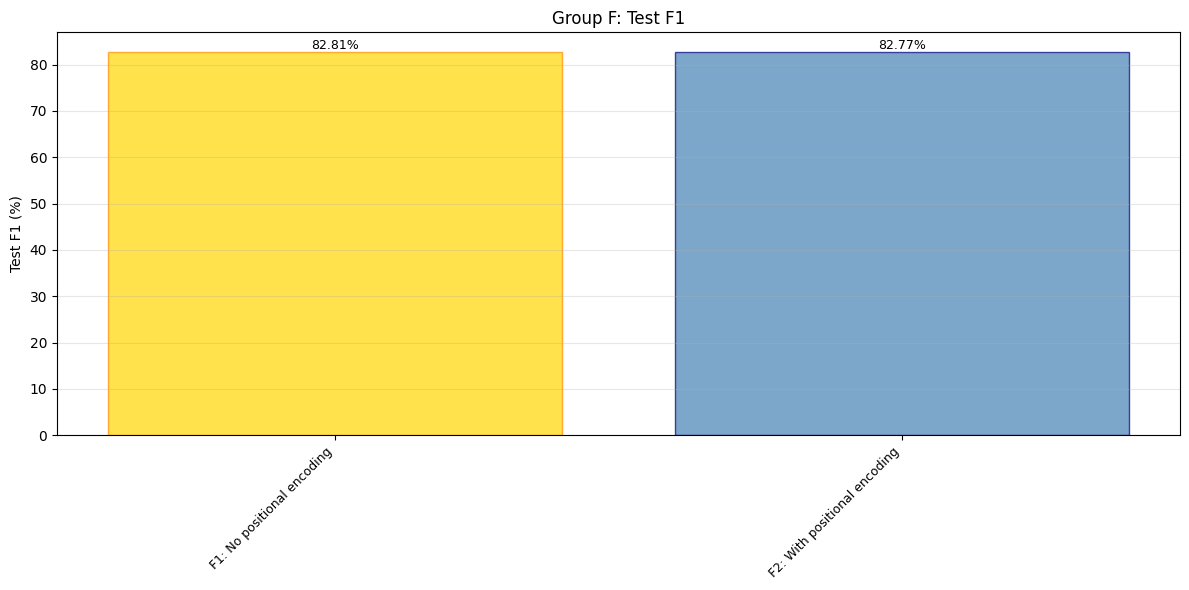

In [ ]:
run_experiments(
    experiments_F,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["F"]
)
plot_group_results('F', metric='test_f1')

### ABLATION GROUP G: Embedding Dimensionality

**Hypothesis**: EEG's lower intrinsic dimensionality compared to images suggests moderate embedding sizes (40-80) are sufficient, unlike language transformers that use 512+ dimensions.

This experiment investigates the impact of embedding size on model capacity and performance, testing whether higher-dimensional representations improve feature learning or cause overfitting.

| Exp ID | Embedding Size | Multi-Scale Filters | Bottleneck Ratio | Params (est.) |
|--------|---------------|-------------------|------------------|---------------|
| G1 | 20 | (4, 8, 8, 8, 2) = 30 | 30→20 (0.67x) | ~0.6M |
| G2 | 40 | (8, 16, 16, 16, 4) = 60 | 60→40 (0.67x) | **~1.0M (baseline)** |
| G3 | 80 | (16, 32, 32, 32, 8) = 120 | 120→80 (0.67x) | ~1.8M |
| G4 | 128 | (26, 50, 50, 50, 14) = 190 | 190→128 (0.67x) | ~2.5M |
| G5 | 256 | (52, 100, 100, 100, 28) = 380 | 380→256 (0.67x) | ~4.2M |

**Configuration**: All experiments use `att_num_layers=8`, `att_num_heads=4`, maintaining the same bottleneck ratio (sum of filters → embedding size reduction).



In [ ]:
experiments_G = [
    ExperimentConfig(
        exp_id='G1',
        group='G',
        description='Small embedding (20 dim)',
        model_params={
            'emb_size': 20,
            'patch_filters_per_scale': (4, 8, 8, 8, 2),
        }
    ),
    ExperimentConfig(
        exp_id='G2',
        group='G',
        description='Baseline embedding (40 dim)',
        model_params={
            'emb_size': 40,
            'patch_filters_per_scale': (8, 16, 16, 16, 4),
        }
    ),
    ExperimentConfig(
        exp_id='G3',
        group='G',
        description='Medium embedding (80 dim)',
        model_params={
            'emb_size': 80,
            'patch_filters_per_scale': (16, 32, 32, 32, 8),
        }
    ),
    ExperimentConfig(
        exp_id='G4',
        group='G',
        description='Large embedding (128 dim)',
        model_params={
            'emb_size': 128,
            'patch_filters_per_scale': (26, 50, 50, 50, 14),
        }
    ),
    ExperimentConfig(
        exp_id='G5',
        group='G',
        description='Very large embedding (256 dim)',
        model_params={
            'emb_size': 256,
            'patch_filters_per_scale': (52, 100, 100, 100, 28),
        }
    ),
    ExperimentConfig(
        exp_id='G6',
        group='G',
        description='Very Very Large Embedding (384 dim)',
        model_params={
            'emb_size': 384,
            'patch_filters_per_scale': (78, 150, 150, 150, 48),
        }
    ),
    ExperimentConfig(
        exp_id='G7',
        group='G',
        description='Huge Embedding (512 dim)',
        model_params={
            'emb_size': 512,
            'patch_filters_per_scale': (104, 200, 200, 200, 64),
        }
    ),
    ExperimentConfig(
    exp_id='G8',
    group='G',
    description='Giant Embedding (768 dim)',
    model_params={
        'emb_size': 768,
        'patch_filters_per_scale': (157, 302, 302, 302, 84),
    }
),
ExperimentConfig(
    exp_id='G9',
    group='G',
    description='God-level Embedding (1024 dim)',
    model_params={
        'emb_size': 1024,
        'patch_filters_per_scale': (209, 402, 402, 402, 112),
    }
),

]

In [ ]:
run_experiments(
    experiments_G,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=REDO_ABLATION["G"]
)
plot_group_results('G', metric='test_f1')

2026-01-25 09:16:11.148 | INFO     | __main__:run_experiments:234 - Running 9 experiments in Group G


Group G:   0%|          | 0/9 [00:00<?, ?it/s]

2026-01-25 09:16:11.158 | INFO     | __main__:train_experiment:103 - Loading cached results for G1
2026-01-25 09:16:11.159 | INFO     | __main__:run_experiments:243 - G1: Test Acc=0.7781, Test F1=0.7775, Params=319,093
2026-01-25 09:16:12.290 | INFO     | __main__:train_experiment:103 - Loading cached results for G2
2026-01-25 09:16:12.291 | INFO     | __main__:run_experiments:243 - G2: Test Acc=0.7908, Test F1=0.7906, Params=834,431
2026-01-25 09:16:13.411 | INFO     | __main__:train_experiment:103 - Loading cached results for G3
2026-01-25 09:16:13.411 | INFO     | __main__:run_experiments:243 - G3: Test Acc=0.7736, Test F1=0.7738, Params=2,466,907
2026-01-25 09:16:16.785 | INFO     | __main__:train_experiment:103 - Loading cached results for G4
2026-01-25 09:16:16.786 | INFO     | __main__:run_experiments:243 - G4: Test Acc=0.7759, Test F1=0.7758, Params=5,443,681
2026-01-25 09:16:17.903 | INFO     | __main__:train_experiment:103 - Loading cached results for G5
2026-01-25 09:16:17.9

Epoch 1/10


KeyboardInterrupt: 

## 7. DEMONSTRATION: Visualizing Model Performance and Embeddings

To provide a more intuitive understanding of our best-performing model (Multi-Scale Dual-Axis Conformer), we will visualize its performance on the test set through:

1.  **Test Set Final Predictions Overview**: A summary of how the model performs on unseen data.
2. **Ablation Test Results**: Summary of the ablation results.
3.  **t-Distributed Stochastic Neighbor Embedding (t-SNE) Visualization**: To understand how the model learns to separate different classes in its latent space. We will extract feature embeddings from a specific layer of the model and project them into a 2D space using t-SNE, coloring the points by their true labels and comparing CTNet against our model.

4. **Missclassifications Analysis**: Through visual inspection of EEG Signals, we will hopefully be able to recognize the most simple patterns that make classes separable or to notice any insight.

### 7.1 Predictions Overview

2026-01-25 09:34:25.803 | INFO     | __main__:<cell line: 0>:33 - Successfully loaded 'best_ms_dual_conformer.h5'.


Test F1-Score: 74.41%
Test Accuracy: 74.46%


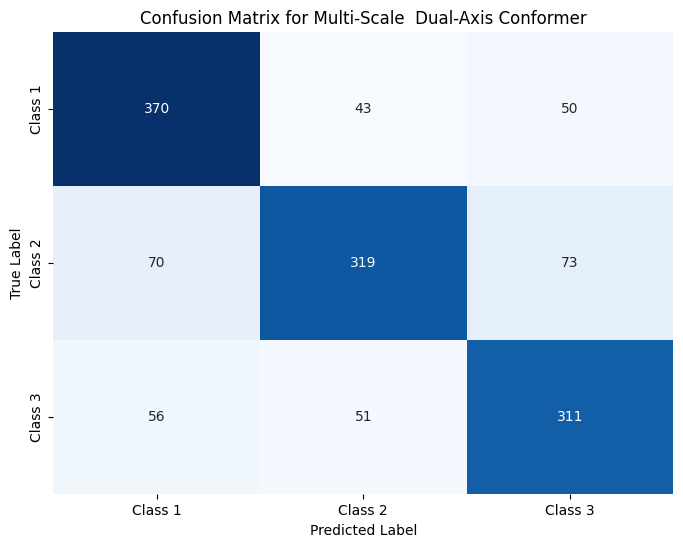

In [ ]:
# Load the MS-DualConformer model directly
try:
    ms_dual_conformer_h5_params = {
        'nb_classes': N,
        'Chans': C,
        'Samples': T,
        'emb_size': 40,
        'patch_kernel_sizes': (5, 12, 25, 64, 125),
        'patch_filters_per_scale': (8, 16, 16, 16, 4),
        'patch_pool_size': 3,
        'patch_channel_temp_filter_size': 4,
        'patch_spatial_droprate': 0.3,
        'patch_final_droprate': 0.3,
        'pe_droprate': 0.2,
        'att_num_layers': 2,
        'att_num_heads': 4,
        'att_dropout': 0.15,
        'pool_droprate': 0.5,
        'fusion_mode': "flatten",
        'classif_hidden_units': (128, 32),
        'classif_droprate_probs': (0.3, 0.25),
        'use_time_embeddings': True,
        'use_channel_embeddings': True,
        'use_cross_time_attention': True,
        'use_cross_channel_attention': True,
        'use_positional_encoding': False,
    }

    best_model = m.MultiScaleDualAxisConformer(**ms_dual_conformer_h5_params)
    best_model.build(input_shape=(None, C, T, 1))
    direct_checkpoint_path = Path('best_ms_dual_conformer.h5')
    best_model.load_weights(str(direct_checkpoint_path))
    logger.info(f"Successfully loaded '{direct_checkpoint_path}'.")

    # Convert y_test to numeric labels and make predictions
    y_test_numeric = np.argmax(y_test, axis=1)
    y_pred_best_model_probs = best_model.predict(X_test, verbose=0)
    y_pred_best_model = np.argmax(y_pred_best_model_probs, axis=1)

except Exception as e:
    logger.error(f"Failed to load best_ms_dual_conformer.h5 or make predictions: {e}")
    best_model = None
    y_pred_best_model = np.array([])
    y_test_numeric = np.array([])

# 1. Test Set Predictions Overview
print(f"Test F1-Score: {raw_metrics_f1[-1]:.2f}%")
print(f"Test Accuracy: {raw_metrics_acc[-1]:.2f}%")

# 2. Confusion Matrix
if best_model is not None and len(y_pred_best_model) > 0 and len(y_test_numeric) > 0:
    cm_best_model = confusion_matrix(y_test_numeric, y_pred_best_model)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_best_model, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[f'Class {i+1}' for i in range(N)],
                yticklabels=[f'Class {i+1}' for i in range(N)])
    plt.title(f'Confusion Matrix for Multi-Scale  Dual-Axis Conformer')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    logger.warning("Best model not loaded or predictions/true labels empty. Cannot generate confusion matrix.")

gc.collect()
plt.close('all')

### 7.2 Ablation Summary

In [ ]:
ablation_summary_df = save_results_summary()
print("Ablation Study Summary:")
display(ablation_summary_df)


2026-01-25 09:34:54.898 | INFO     | __main__:save_results_summary:390 - Saved summary to ablation_results/ablation_summary.csv


Ablation Study Summary:


,exp_id,group,description,timestamp,train_acc,val_acc,test_acc,train_f1,val_f1,test_f1,train_loss,val_loss,num_params,training_time_seconds,best_epoch,confusion_matrix
0,A11,A,Single-scale alpha band (~10Hz),2026-01-14T15:03:22.254245,0.932332,0.821990,0.812500,0.932125,0.820149,0.812776,0.437684,0.615674,878079,381.905224,10,"[[53, 4, 8], [5, 49, 9], [5, 5, 54]]"
1,A12,A,Single-scale theta band (~4Hz),2026-01-14T15:10:02.119512,0.947563,0.816754,0.812500,0.947629,0.816445,0.812310,0.399465,0.568894,880419,367.767290,10,"[[53, 7, 5], [6, 55, 2], [6, 10, 48]]"
2,A13,A,"3-scale (gamma, alpha, delta)",2026-01-14T19:51:56.989483,0.926893,0.827225,0.817708,0.927013,0.826766,0.818310,0.425712,0.577195,879679,372.373493,9,"[[55, 1, 9], [6, 49, 8], [6, 5, 53]]"
3,A1a,A1,Single-scale alpha band (~10Hz),2026-01-17T14:53:32.196271,0.932775,0.777364,0.783321,0.932736,0.776988,0.783345,0.356544,0.637566,833775,301.744521,10,"[[375, 41, 47], [51, 355, 56], [54, 42, 322]]"
4,A1b,A1,Single-scale theta band (~4Hz),2026-01-17T14:59:03.618033,0.914488,0.784810,0.786299,0.914499,0.784554,0.785871,0.353502,0.670141,836115,293.780343,9,"[[378, 42, 43], [40, 373, 49], [57, 56, 305]]"
5,A1c,A1,"3-scale (gamma, alpha, delta)",2026-01-17T15:04:18.206509,0.861024,0.780343,0.775130,0.861012,0.780409,0.775051,0.386777,0.629913,835375,276.107697,6,"[[367, 47, 49], [49, 362, 51], [52, 54, 312]]"
6,A1d,A1,5-scale balanced,2026-01-17T15:10:00.694721,0.934395,0.796724,0.772897,0.934332,0.796819,0.772875,0.343279,0.608560,835047,298.073890,10,"[[376, 36, 51], [51, 351, 60], [59, 48, 311]]"
7,A2a,A2,Full spectrum coverage (100Hz → 2Hz),2026-01-17T15:42:46.567086,0.925345,0.796724,0.779598,0.925264,0.796604,0.779915,0.361050,0.649088,834907,342.892925,10,"[[365, 44, 54], [44, 352, 66], [51, 37, 330]]"
8,A2b,A2,Standard 5-scale (missing theta gap),2026-01-17T15:48:18.282901,0.931229,0.788533,0.773641,0.931156,0.788824,0.774114,0.353635,0.590782,835047,302.732998,10,"[[356, 45, 62], [44, 351, 67], [36, 50, 332]]"
9,A2c,A2,Mid-range only (beta-alpha-theta),2026-01-17T15:53:42.207606,0.915214,0.780343,0.784810,0.915276,0.780196,0.784651,0.345683,0.680220,834015,294.660763,9,"[[370, 53, 40], [53, 371, 38], [52, 53, 313]]"


<Axes: >

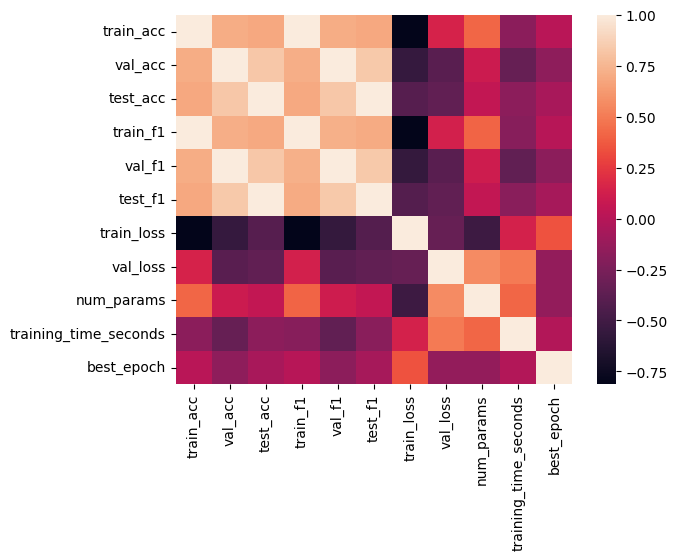

In [122]:
numeric_df = ablation_summary_df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr())

### 7.3 t-SNE Latent Space Visualization

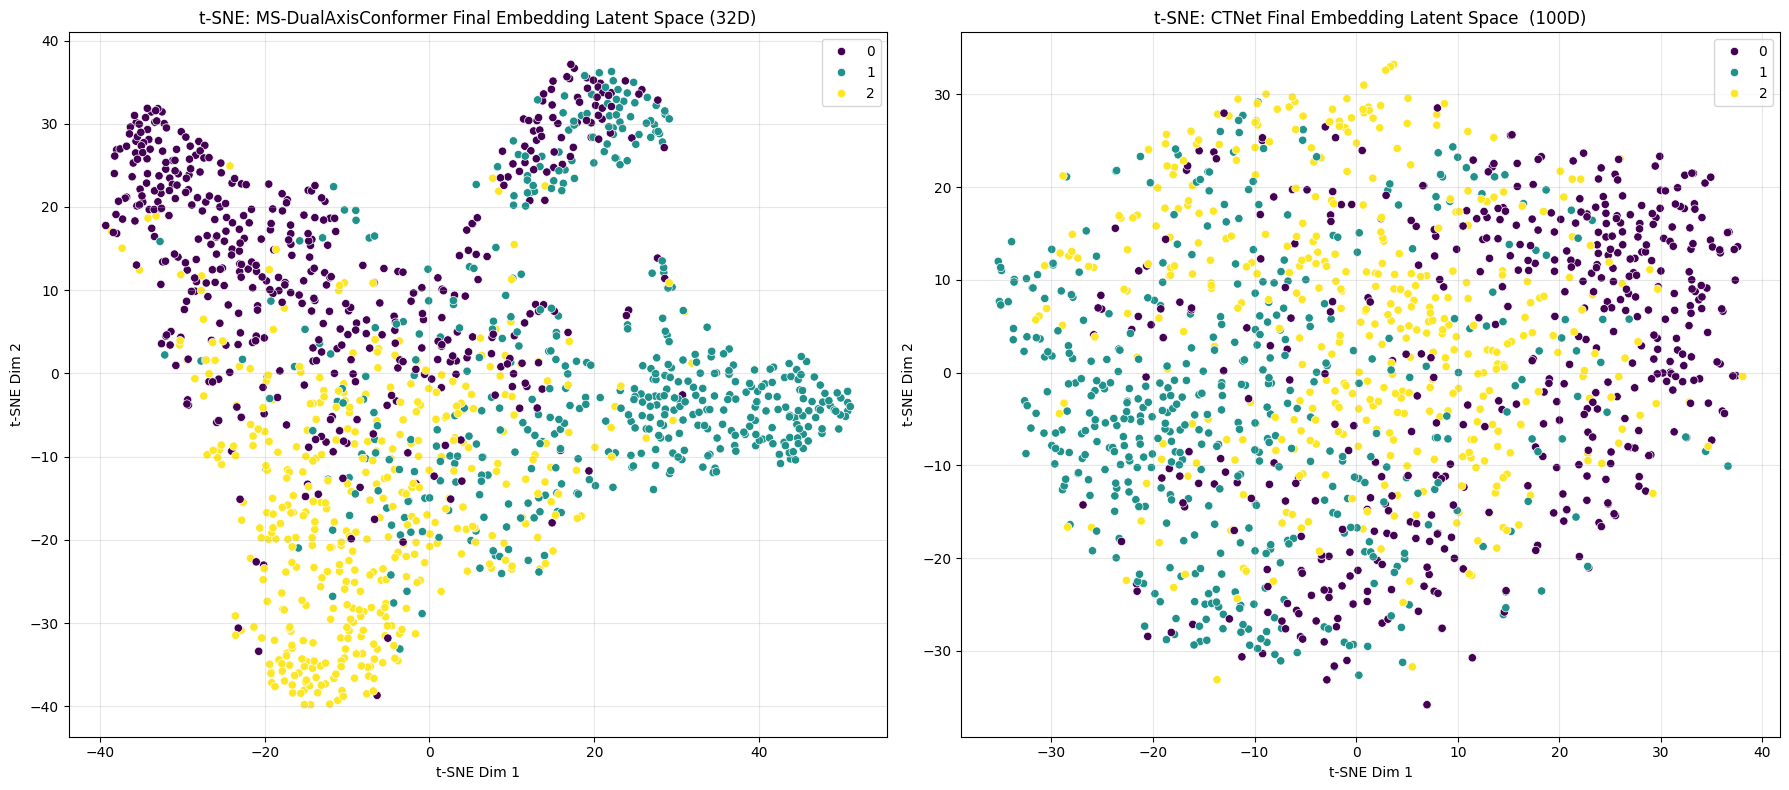

In [ ]:
# ------------------------------------------------------------
# 1. Penultimate-layer embedding extractor (TF-correct)
# ------------------------------------------------------------
def extract_embeddings(model, x):
    """
    Extract penultimate-layer embeddings from a tf.keras.Model.
    Assumes last layer is the classifier.
    """
    emb_layer = model.layers[-2]
    emb_model = tf.keras.Model(inputs=model.input, outputs=emb_layer.output)
    return emb_model.predict(x, verbose=0)


# ------------------------------------------------------------
# 2. CTNet loader
# ------------------------------------------------------------
def load_ctnet(weights_path, params, input_shape):
    model = m.CTNet(**params)
    model.build(input_shape)
    model.load_weights(weights_path)
    return model


# ------------------------------------------------------------
# 3. t-SNE comparison plot
# ------------------------------------------------------------
def tsne_compare(emb_a, emb_b, labels, seed, titles):
    perplexity = min(30, max(5, len(labels) - 1))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        n_jobs=-1,
    )

    emb_a_2d = tsne.fit_transform(emb_a)
    emb_b_2d = tsne.fit_transform(emb_b)

    plt.figure(figsize=(18, 8))

    for i, (emb, title) in enumerate(
        zip([emb_a_2d, emb_b_2d], titles), start=1
    ):
        plt.subplot(1, 2, i)
        sns.scatterplot(
            x=emb[:, 0],
            y=emb[:, 1],
            hue=labels,
            palette="viridis",
            legend="full",
        )
        plt.title(title)
        plt.xlabel("t-SNE Dim 1")
        plt.ylabel("t-SNE Dim 2")
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Run everything
# ------------------------------------------------------------

# MS-DualAxisConformer embeddings
ms_embeddings = extract_embeddings(best_model, X_test)

# CTNet parameters
ctnet_params = {
    "nb_classes": N,
    "Chans": C,
    "Samples": T,
    "num_heads": 10,
    "num_layers": 16,
    "attn_drop_rate": 0.1,
    "cnn_drop_rate": 0.25,
    "final_drop_rate": 0.25,
    "n_filters_time": 5,
    "pool_size_1": 4,
    "pool_size_2": 4,
}

# Load CTNet
ctnet = load_ctnet(
    weights_path="best_ctnet.h5",
    params=ctnet_params,
    input_shape=(None, C, T, 1),
)

ct_embeddings = extract_embeddings(ctnet, X_test)

# Compare latent spaces
tsne_compare(
    ms_embeddings,
    ct_embeddings,
    y_test_numeric,
    seed=config["seed"],
    titles=[
        "t-SNE: MS-DualAxisConformer Final Embedding Latent Space (32D)",
        "t-SNE: CTNet Final Embedding Latent Space  (100D)",
    ],
)

# Cleanup
del ms_embeddings, ct_embeddings, ctnet
gc.collect()
tf.keras.backend.clear_session()


### 7.4 Missclassifications in EEG Visualization

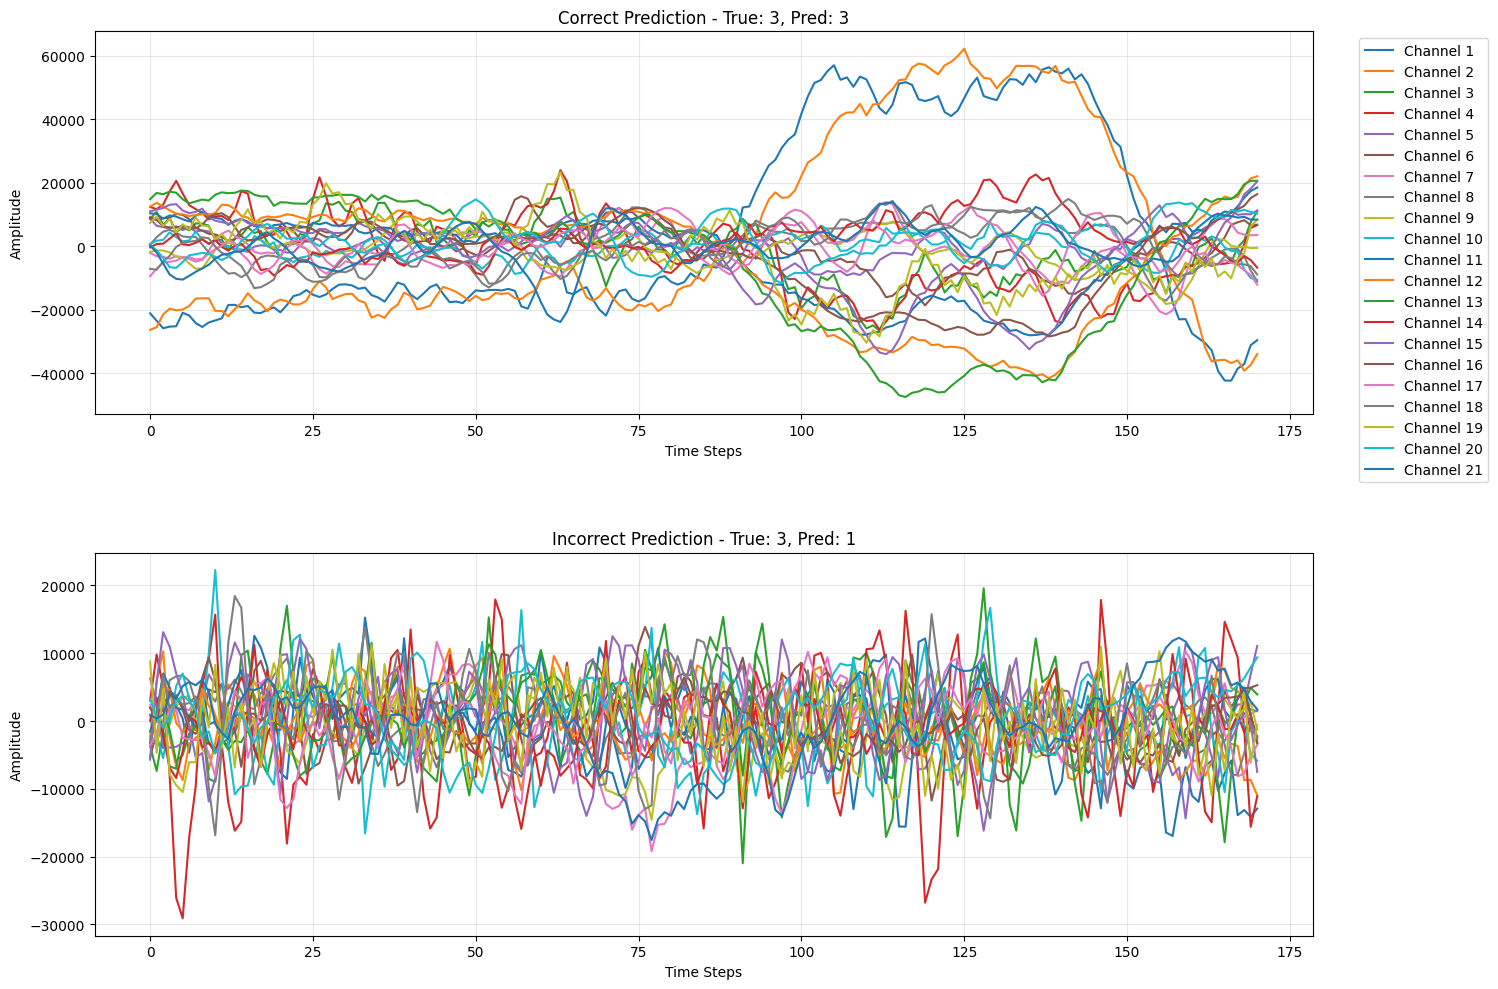

Correct Example - True: Class 3, Pred: Class 3
Incorrect Example - True: Class 3, Pred: Class 1


11384

In [120]:
# Parameters
N_CORRECT = 1
N_INCORRECT = 1

# Get indices
correct_idx = np.where(y_pred_best_model == y_test_numeric)[0].tolist()
incorrect_idx = np.where(y_pred_best_model != y_test_numeric)[0].tolist()

# Sample randomly if enough examples
selected_correct = random.sample(correct_idx, min(N_CORRECT, len(correct_idx)))
selected_incorrect = random.sample(incorrect_idx, min(N_INCORRECT, len(incorrect_idx)))

# Combine
selected_examples = [('Correct', idx) for idx in selected_correct] + \
                    [('Incorrect', idx) for idx in selected_incorrect]

if not selected_examples:
    print("No examples to display.")
else:
    plt.figure(figsize=(15, 5*len(selected_examples)))
    for i, (label_type, idx) in enumerate(selected_examples):
        eeg = X_test[idx]
        true_lbl = y_test_numeric[idx]
        pred_lbl = y_pred_best_model[idx]

        plt.subplot(len(selected_examples), 1, i+1)
        plt.plot(eeg.squeeze().T)
        plt.title(f"{label_type} Prediction - True: {true_lbl+1}, Pred: {pred_lbl+1}")
        plt.xlabel("Time Steps")
        plt.ylabel("Amplitude")
        plt.grid(alpha=0.3)
        if i == 0:
            plt.legend([f"Channel {ch+1}" for ch in range(eeg.shape[0])], loc='upper right', bbox_to_anchor=(1.15,1))
    plt.tight_layout()
    plt.show()

# Print summary
for label_type, idx in selected_examples:
    true_lbl = y_test_numeric[idx]
    pred_lbl = y_pred_best_model[idx]
    print(f"{label_type} Example - True: Class {true_lbl+1}, Pred: Class {pred_lbl+1}")

gc.collect()
